# HHBANK - 2 COUNTRY GITHUB VERSION 

In [1]:
# PACKAGES AND PATHS 
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np


from pathlib import Path
import numpy as np
from sequence_jacobian import grids

try:
    BASE_DIR_D = Path(__file__).resolve().parent
except NameError:
    BASE_DIR_D = Path.cwd()


DATA_DIR_D = BASE_DIR_D / "Discretisation" / "Outputs"


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CALIBRATION
# ═══════════════════════════════════════════════════════════════════════
calibration_start = {

    # ── Preferences ──────────────────────────────────────────────────────
    #                              D               F
    'frisch_D':     1.0,    'frisch_F':     1.0,    # Frisch elasticity of labour supply
    'eis_D':        0.5,    'eis_F':        0.5,    # Elasticity of intertemporal substitution

    # ── Rates & Asset Prices ─────────────────────────────────────────────
    'rdep_D':       0.000, 'rdep_F':       0.000, # Real deposit rate (initial guess; endogenous in transition)
    'q_b_D':        0.82,   'q_b_F':        0.83,   # Bond price (initial guess)
    'Q_D':          1.0,    'Q_F':          1.0,    # Tobin's q

    # ── Production ───────────────────────────────────────────────────────
    'alpha_D':      0.35,   'alpha_F':      0.35,   # Capital share
    'delta_D':      0.025, 'delta_F':      0.025,   # Quarterly depreciation rate
    'ksi_D':        0.5,    'ksi_F':        0.5,    # Capital adjustment cost curvature

    # ── Long-term bonds ───────────────────────────────────────────────────
    'delta_b_D':   0.05,   'delta_b_F':    0.05,

    # ── Aggregate Targets (SS) ───────────────────────────────────────────
    'Y_D':          1.00,   'Y_F':          1.00,   # Output
    'Y_ss_D':       1.0,    'Y_ss_F':       1.0,    # SS output anchor (government_default debt-gap)
    'N_D':          1.00,   'N_F':          1.00,   # Labour
    'w_D':          0.65,   'w_F':          0.65,   # Real wage

    # ── Financial Intermediaries (Gertler-Karadi) ─────────────────────────
    'f_D':          0.06,   'f_F':          0.06,   # Exit probability
    'lambda_gk_D':  0.2,    'lambda_gk_F':  0.2,    # Divertability fraction (IC constraint & P1 Bellman)
    # Intermediary-specific discount factors (distinct from household beta_D/beta_F).
    # These govern bond pricing (bond_price_ss_*) and banker Bellman (intermediation_P1_*).
    # Calibrate to target empirical steady-state bond yields rb_actual_D / rb_actual_F.
    'beta_inter_D': 0.985,  'beta_inter_F': 0.985,  # Banker discount factors
    'Delta_bD_D':   0.2,    'Delta_bF_F':   0.2,    # Domestic bonds (preferred — better collateral)
    'Delta_bF_D':   0.4,    'Delta_bD_F':   0.4,    # Foreign bonds (penalised — weaker collateral)
    'lambda_BD_D':  0.06,   'lambda_BF_F':  0.06,   # Domestic bond risk-weight (FOC spread)
    'lambda_BF_D':  0.06,   'lambda_BD_F':  0.06,   # Foreign bond risk-weight (FOC spread)
    'psi_lambda_B_D': 1.5,  'psi_lambda_B_F': 1.5,  # State-dependence of bond divertability (0 = off)
    'n_inter_D':    0.75*4, 'n_inter_F':    0.75*4, # Bank net worth
    'theta_D':      4,      'theta_F':      4,      # Leverage ratio

    # ── Bellman nu risk-discount ──────────────────────────────────────────
    'psi_nu_bD_D':  0.0,    'psi_nu_bD_F':  0.0,   # Risk-discount on D-bonds (def_rate_D)
    'psi_nu_bF_D':  0.0,    'psi_nu_bF_F':  0.0,   # Risk-discount on F-bonds (def_rate_F)

    # ── Fiscal & Government Debt ─────────────────────────────────────────
    'B_supply_D':   0.6*4,  'B_supply_F':   0.6*4,  # Total bond supply — face value (≈ 60% of annual GDP)
    'b_gov_D':      0.6*4,  'b_gov_F':      0.6*4,  # Government bonds outstanding (face value)
    'b_gov_ss_D':   0.6*4,  'b_gov_ss_F':   0.6*4,  # SS debt anchor

    # ── Fiscal Rule (transfers) ──────────────────────────────────────────
    'tau_D':        0.181,  'tau_F':        0.181,  # Tax rate
    'lamb_D':       0.85,   'lamb_F':       0.85,   # Transfer-to-output ratio
    'lamb_ss_D':    0.85,   'lamb_ss_F':    0.85,   # SS transfer anchor
    'phi_lamb_D':   0.4,    'phi_lamb_F':   0.4,    # Surplus response to debt gap (Bohn rule)

    # ── Sovereign Default ────────────────────────────────────────────────
    'shock_def_D':      0.000,  'shock_def_F':      0.0,    # Exogenous default shock
    'def_rate_D':       0.000,  'def_rate_F':       0.0,    # Default rate (SS = 0)
    'def_scale_D':      0.0,    'def_scale_F':      0.0,    # Endogenous default sensitivity
    'def_curvature_D':  0.5,    'def_curvature_F':  0.5,    # Power-function curvature
    'def_offset_D':     0.05,   'def_offset_F':     0.05,   # Linearisation offset
    'recovery_rate_D':  0.40,   'recovery_rate_F':  0.40,   # Recovery on defaulted debt
    'zeta_writeoff_D':  1.0,    'zeta_writeoff_F':  1.0,    # 1 = full write-off; 0 = coupon haircut
    'writeoff_enabled_D': 0.0,  'writeoff_enabled_F': 0.0,  # 0 = pure risk shock (no write-off); 1 = write-off regime

    # ── Intermediary Capital Adjustment Cost (Auclert 2019) ──────────────
    'chi0_D':           0.01,   'chi0_F':           0.01,   # Regularisation constant (prevents division by zero)
    'chi1_D':           2.5,    'chi1_F':           2.5,    # Cost scale
    'chi2_D':           2.0,    'chi2_F':           2.0,    # Cost curvature (2 = quadratic)

    # ── Macroprudential Bond Tax ──────────────────────────────────────────
    'T0_D':             0.000,  'T0_F':             0.000,  # Flat per-bond tax (breaks portfolio indeterminacy)
    'T1_D':             0.0,    'T1_F':             0.0,    # Sensitivity to default probability 

    # ── Trade & Terms of Trade ───────────────────────────────────────────
    'omega':            0.85,   # Home bias in consumption
    'epsilon_trade':    1.5,    # Trade elasticity
    'p':                1.0,    # Terms of trade (Guess)

    # ── Cross-Border Bond Portfolio ──────────────────────────────────────
    'phi_bF_D_ss':  0.25,   'phi_bD_F_ss':  0.25,   # Initial portfolio shares (used to seed b_F_D/b_D_F)
    'psi_bF_D':     0.5,    'psi_bD_F':     0.5,    # Portfolio adjustment cost (level-based)

    # ── Wage Markups (calibrate vphi via labor_ss) ───────────────────────
    'mu_w_D':       1.0,    'mu_w_F':       1.0,    # Wage markup (SS; used by labor_ss to pin vphi)

    # ── SS Real Variables ─────────────────────────────────────────────────
    'mc_D':         1.0,    'mc_F':         1.0,    # Marginal cost (= 1 under flexible prices)

    # ── Idiosyncratic Income Process (Rouwenhorst grid) ──────────────────
    'rho_z_D':  0.90,    'rho_z_F':  0.90,           # AR(1) persistence
    'sigma_z_D': 0.3,   'sigma_z_F': 0.3,           # Innovation std dev
    'nZ_D':     7,     'nZ_F':     7,             # Income grid points
    'nDep_D':   500,    'nDep_F':   500,            # Deposit grid points
    'Depmax_D': 150,    'Depmax_F': 150,            # Max deposit (borrowing limit)
}

calibration_start_D = {k: v for k, v in calibration_start.items() if k.endswith('_D')}
calibration_start_F = {k: v for k, v in calibration_start.items() if k.endswith('_F')}

calibration_hh_D = {**calibration_start_D, 'beta_D': 0.9920094934, 'div_D': 0.19}
calibration_hh_F = {**calibration_start_F, 'beta_F': 0.9870643761, 'div_F': 0.21}

In [3]:
# ── Bond Holdings (initial SS guess; portfolio anchors overwritten post-solve) ──
_n_D, _n_F = calibration_start['n_inter_D'], calibration_start['n_inter_F']
_B_D, _B_F = calibration_start['B_supply_D'], calibration_start['B_supply_F']

b_F_D = calibration_start['phi_bF_D_ss'] * _n_D / calibration_start['q_b_F']
b_D_F = calibration_start['phi_bD_F_ss'] * _n_F / calibration_start['q_b_D']

calibration_start.update({
    'b_F_D': b_F_D,        'b_D_F': b_D_F,
    'b_D_D': _B_D - b_D_F, 'b_F_F': _B_F - b_F_D,
    'b_F_D_anchor': b_F_D, 'b_D_F_anchor': b_D_F,   # initial guess; overwritten post-solve
    'psi_bD_D': 0.5,        'psi_bF_F': 0.5,
})


In [4]:
from equations_D import (hh_init_D, hh_D, make_grids_D, income_D, hh_extended_D)
from equations_F import (hh_init_F, hh_F, make_grids_F, income_F, hh_extended_F)

### EQUATIONS

#### STEADY STATE EQUATIONS

In [5]:
from equations_D import (
    smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, sdf_D, sdf_ss_D, government_ss_D, labor_ss_D,
    government_default_D, bond_price_ss_D, bond_return_D,
    ces_price_D, import_demand_D, deposit_return_D,
)

from equations_F import (
    smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, sdf_F, sdf_ss_F, government_ss_F, labor_ss_F,
    government_default_F, bond_price_ss_F, bond_return_F,
    ces_price_F, import_demand_F, deposit_return_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_level_anchors, portfolio_adj_cost, bond_yield,
    global_goods_mkt, external_account_D,
)


### SOLVING MODEL

#### STEADY STATE

In [6]:
import copy

ha = sj.create_model([
    sdf_ss_D, sdf_banker_ss_D, government_default_D, bond_price_ss_D, bond_return_D,
    sdf_ss_F, sdf_banker_ss_F, government_default_F, bond_price_ss_F, bond_return_F,
    hh_extended_D, smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, government_ss_D, labor_ss_D,
    hh_extended_F, smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, government_ss_F, labor_ss_F,
    ces_price_D, import_demand_D, ces_price_F, import_demand_F,
    deposit_return_D, deposit_return_F,
    bond_yield,
    trade_balance, external_account_D, global_goods_mkt,
], name='MU HA Model 2 Country')

unknowns_ss = {'beta_D': 0.9850 ,'beta_F': 0.9850, 'p': 0.99}
targets_ss  = ['deposit_mkt_D', 'deposit_mkt_F', 'ca_res_D']

ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss, solver='broyden_custom')

# ── Post-solve anchors ────────────────────────────────────────────────────────
anchors = {
    # Share-based values for bond portfolio FOCs (divert_bond_foc_D/F)
    'phi_bD_D_ss':           float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D']),
    'phi_bF_F_ss':           float(ss['q_b_F']) * float(ss['b_F_F']) / (float(ss['p']) * float(ss['n_inter_F'])),
    # Level anchors → portfolio_level_anchors block → b_F_D_ss, b_D_F_ss
    'b_F_D_anchor':          float(ss['b_F_D']),
    'b_D_F_anchor':          float(ss['b_D_F']),
    # Excess returns used by divert_bond_foc_D/F and divert_portfolio_adj
    'excess_return_bD_D_ss': float(ss['rb_actual_D']) - float(ss['rdep_D']) - calibration_start['T0_D'],
    'excess_return_bF_F_ss': float(ss['rb_actual_F']) - float(ss['rdep_F']) - calibration_start['T0_F'],
    'excess_return_F_D_ss':  float(ss['rb_actual_F']) - float(ss['rdep_D']) - calibration_start['T0_D'],
    'excess_return_D_F_ss':  float(ss['rb_actual_D']) - float(ss['rdep_F']) - calibration_start['T0_F'],
    'q_b_D':                 float(ss['q_b_D']),
    'q_b_F':                 float(ss['q_b_F']),
    'p':                     float(ss['p']),
    # SS consumption levels — denominators for welfare_agg_D/F normalisation
    'C_D_ss':                float(ss['C_D']),
    'C_F_ss':                float(ss['C_F']),
}
calibration_start.update(anchors)
for k, v in anchors.items():
    ss.toplevel[k] = v

ss.toplevel['b_F_D_ss'] = float(ss['b_F_D'])
ss.toplevel['b_D_F_ss'] = float(ss['b_D_F'])


ss.toplevel['Rgross_D'] = float(1 + ss['rdep_D'])
ss.toplevel['Rgross_F'] = float(1 + ss['rdep_F'])

_fr_D = float(ss['frisch_D']); _fr_F = float(ss['frisch_F'])
ss.toplevel['X_D'] = float(ss['C_D']) - float(ss['vphi_D']) * float(ss['N_D']) ** (1 + 1/_fr_D) / (1 + 1/_fr_D)
ss.toplevel['X_F'] = float(ss['C_F']) - float(ss['vphi_F']) * float(ss['N_F']) ** (1 + 1/_fr_F) / (1 + 1/_fr_F)
ss.toplevel['U_D'] = ss.toplevel['X_D'] / float(ss['C_D'])
ss.toplevel['U_F'] = ss.toplevel['X_F'] / float(ss['C_F'])

ss.toplevel['Phi_D'] = float(ss['Phi_D'])
ss.toplevel['Phi_F'] = float(ss['Phi_F'])

# Seed value_D/F: franchise value per unit net worth consumed as lead by intermediation_P1.
# SS identity: value = beta*Omega*(1+rn) = lambda_gk*theta_div (binding IC).
ss.toplevel['value_D'] = float(ss['beta_inter_D']) * float(ss['Omega_D']) * (1 + float(ss['rn_D']))
ss.toplevel['value_F'] = float(ss['beta_inter_F']) * float(ss['Omega_F']) * (1 + float(ss['rn_F']))

for k, v in {
    'tau_mp_D':        0.0,  'tau_mp_F':        0.0,
    'T_D':             0.0,  'T_F':             0.0,
    'b_F_D_res':       0.0,  'b_D_F_res':       0.0,
    'rb_D_res':        0.0,  'rb_F_res':        0.0,
    'labor_mkt_res_D': 0.0,  'labor_mkt_res_F': 0.0,
    'w_res_D':         0.0,  'w_res_F':         0.0,
}.items():
    ss.toplevel[k] = v
cali_D = cali_F = ss
ss_final = copy.deepcopy(ss)

NameError: name 'sdf_banker_ss_D' is not defined

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# POST-SOLVE ANCHOR HELPER
# Re-applies all ss.toplevel / calibration_start anchors after any SS re-solve.
# Must be called whenever ha.solve_steady_state is called during calibration.
# ─────────────────────────────────────────────────────────────────────────────
import copy

def _apply_ss_anchors(ss_in, cal):
    """Sync ss_in.toplevel and cal with fresh post-SS values."""
    anchors = {
        'phi_bD_D_ss':           float(ss_in['q_b_D']) * float(ss_in['b_D_D']) / float(ss_in['n_inter_D']),
        'phi_bF_F_ss':           float(ss_in['q_b_F']) * float(ss_in['b_F_F']) / (float(ss_in['p']) * float(ss_in['n_inter_F'])),
        'b_F_D_anchor':          float(ss_in['b_F_D']),
        'b_D_F_anchor':          float(ss_in['b_D_F']),
        'excess_return_bD_D_ss': float(ss_in['rb_actual_D']) - float(ss_in['rdep_D']) - cal['T0_D'],
        'excess_return_bF_F_ss': float(ss_in['rb_actual_F']) - float(ss_in['rdep_F']) - cal['T0_F'],
        'excess_return_F_D_ss':  float(ss_in['rb_actual_F']) - float(ss_in['rdep_D']) - cal['T0_D'],
        'excess_return_D_F_ss':  float(ss_in['rb_actual_D']) - float(ss_in['rdep_F']) - cal['T0_F'],
        'q_b_D':   float(ss_in['q_b_D']),
        'q_b_F':   float(ss_in['q_b_F']),
        'p':       float(ss_in['p']),
        'C_D_ss':  float(ss_in['C_D']),
        'C_F_ss':  float(ss_in['C_F']),
    }
    cal.update(anchors)
    for k, v in anchors.items():
        ss_in.toplevel[k] = v
    ss_in.toplevel['b_F_D_ss']  = float(ss_in['b_F_D'])
    ss_in.toplevel['b_D_F_ss']  = float(ss_in['b_D_F'])
    ss_in.toplevel['Rgross_D']  = float(1 + ss_in['rdep_D'])
    ss_in.toplevel['Rgross_F']  = float(1 + ss_in['rdep_F'])
    _fr_D = float(ss_in['frisch_D']); _fr_F = float(ss_in['frisch_F'])
    ss_in.toplevel['X_D']   = (float(ss_in['C_D'])
                                - float(ss_in['vphi_D']) * float(ss_in['N_D'])**(1+1/_fr_D) / (1+1/_fr_D))
    ss_in.toplevel['X_F']   = (float(ss_in['C_F'])
                                - float(ss_in['vphi_F']) * float(ss_in['N_F'])**(1+1/_fr_F) / (1+1/_fr_F))
    ss_in.toplevel['U_D']   = ss_in.toplevel['X_D'] / float(ss_in['C_D'])
    ss_in.toplevel['U_F']   = ss_in.toplevel['X_F'] / float(ss_in['C_F'])
    ss_in.toplevel['Phi_D'] = float(ss_in['Phi_D'])
    ss_in.toplevel['Phi_F'] = float(ss_in['Phi_F'])
    ss_in.toplevel['value_D'] = (float(ss_in['beta_inter_D'])
                                  * float(ss_in['Omega_D']) * (1 + float(ss_in['rn_D'])))
    ss_in.toplevel['value_F'] = (float(ss_in['beta_inter_F'])
                                  * float(ss_in['Omega_F']) * (1 + float(ss_in['rn_F'])))
    for k, v in {
        'tau_mp_D': 0.0, 'tau_mp_F': 0.0,
        'T_D': 0.0,  'T_F': 0.0,
        'b_F_D_res': 0.0, 'b_D_F_res': 0.0,
        'rb_D_res': 0.0,  'rb_F_res': 0.0,
        'labor_mkt_res_D': 0.0, 'labor_mkt_res_F': 0.0,
        'w_res_D': 0.0, 'w_res_F': 0.0,
    }.items():
        ss_in.toplevel[k] = v
    return anchors


## Section 1.2 — Portfolio Share Targeting and Delta Calibration

Set `b_D_D, b_F_D` so that D-bank portfolio shares hit empirical targets.  
F-bank shares are the residuals from bond-market clearing.  
Delta values are then back-solved analytically from the GK incentive-compatibility constraint so that IC binds at the chosen portfolio composition.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1.2 — Portfolio Share Targeting + Delta Calibration
# ═══════════════════════════════════════════════════════════════════════════════
# Why direct bond allocation (not Delta outer-loop)?
# In the simple SS model `ha`, Delta only appears in intermediation_IC which is
# NOT included in `ha`. Changing Delta therefore has zero effect on ha's SS.
# The correct approach: directly set bond holdings to hit the portfolio targets,
# re-solve the SS, then back-solve Delta from the IC identity so that the IC
# constraint binds at the new portfolio composition in the dynamic model ha_full.

# ── Targets (edit to match empirical data) ────────────────────────────────────
target_phi_bD_D = 0.35   # D-bank NW share held in D-bonds
target_phi_bF_D = 0.15   # D-bank NW share held in F-bonds
# F-bank residuals are implied by bond-market clearing (see below).
# Reference F-bank targets from doc (reported for comparison only):
target_phi_bD_F_ref = 0.18
target_phi_bF_F_ref = 0.30

# ── Read current SS values ────────────────────────────────────────────────────
n_D  = float(ss['n_inter_D'])
n_F  = float(ss['n_inter_F']) * float(ss['p'])   # F-bank NW in D-goods
q_D  = float(ss['q_b_D'])
q_F  = float(ss['q_b_F'])
p_ss = float(ss['p'])
B_D  = float(calibration_start['B_supply_D'])    # total D-bond face value
B_F  = float(calibration_start['B_supply_F'])    # total F-bond face value

# ── Step 1: Set bond holdings to hit D-bank targets ──────────────────────────
b_D_D_new = target_phi_bD_D * n_D / q_D    # D-bank holds D-bonds
b_F_D_new = target_phi_bF_D * n_D / q_F    # D-bank holds F-bonds
# Bond-market clearing: remaining goes to F-bank
b_D_F_new = B_D - b_D_D_new
b_F_F_new = B_F - b_F_D_new

# Implied F-bank shares (for reference; may differ from targets)
phi_bD_F_implied = q_D * b_D_F_new / n_F
phi_bF_F_implied = q_F * b_F_F_new / n_F

print("── Portfolio share targets (D-bank) ──")
print(f"  phi_bD_D = {target_phi_bD_D:.3f}  phi_bF_D = {target_phi_bF_D:.3f}")
print("── Implied F-bank shares (residual from bond-market clearing) ──")
print(f"  phi_bD_F = {phi_bD_F_implied:.3f}  (ref target {target_phi_bD_F_ref:.3f})")
print(f"  phi_bF_F = {phi_bF_F_implied:.3f}  (ref target {target_phi_bF_F_ref:.3f})")

calibration_start.update({
    'b_D_D': b_D_D_new, 'b_F_D': b_F_D_new,
    'b_D_F': b_D_F_new, 'b_F_F': b_F_F_new,
    'b_F_D_anchor': b_F_D_new, 'b_D_F_anchor': b_D_F_new,
    'phi_bF_D_ss': target_phi_bF_D,  # update initial-share anchor
})

# ── Step 2: Re-solve SS with new bond allocation ──────────────────────────────
print("\nRe-solving SS with new portfolio allocation...")
ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss,
                            solver='broyden_custom')
_apply_ss_anchors(ss, calibration_start)
print(f"SS re-solved. beta_D={float(ss['beta_D']):.8f}  p={float(ss['p']):.6f}")

# ── Step 3: Back-solve Delta from IC constraint ───────────────────────────────
# IC (binding): theta = value/lambda + (1-Delta_own)*phi_own + (1-Delta_cross)*phi_cross
# Parameterise: Delta_cross = ratio * Delta_own  (foreign bonds more divertable).
# Then: Delta_own = (phi_own + phi_cross - (theta - value/lam)) / (phi_own + ratio*phi_cross)

ratio_D = 2.0   # Delta_bF_D / Delta_bD_D  (F-bonds are foreign to D-bank → more divertable)
ratio_F = 2.0   # Delta_bD_F / Delta_bF_F  (D-bonds are foreign to F-bank → more divertable)

def _ic_delta(phi_own, phi_cross, nu_K, nu_b_own, nu_b_cross, eta, lam, theta, ratio):
    """Solve for (delta_own, delta_cross) from IC binding condition."""
    kappa    = theta - phi_own - phi_cross
    value    = nu_K * kappa + nu_b_own * phi_own + nu_b_cross * phi_cross + eta
    denom    = phi_own + ratio * phi_cross
    delta_own = (phi_own + phi_cross - (theta - value / lam)) / denom
    return float(delta_own), float(ratio * delta_own), float(value)

# D-bank (own = D-bonds, cross = F-bonds)
phi_bD_D_ss = float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D'])
phi_bF_D_ss = float(ss['q_b_F']) * float(ss['b_F_D']) / float(ss['n_inter_D'])
D_bD_D, D_bF_D, val_D = _ic_delta(
    phi_bD_D_ss, phi_bF_D_ss,
    float(ss['nu_K_D']), float(ss['nu_bD_D']), float(ss['nu_bF_D']), float(ss['eta_D']),
    float(ss['lambda_gk_D']), float(ss['theta_D']), ratio_D
)

# F-bank (own = F-bonds, cross = D-bonds)
n_F_ss    = float(ss['n_inter_F']) * float(ss['p'])
phi_bF_F_ss = float(ss['q_b_F']) * float(ss['b_F_F']) / n_F_ss
phi_bD_F_ss = float(ss['q_b_D']) * float(ss['b_D_F']) / n_F_ss
D_bF_F, D_bD_F, val_F = _ic_delta(
    phi_bF_F_ss, phi_bD_F_ss,
    float(ss['nu_K_F']), float(ss['nu_bF_F']), float(ss['nu_bD_F']), float(ss['eta_F']),
    float(ss['lambda_gk_F']), float(ss['theta_F']), ratio_F
)

calibration_start.update({
    'Delta_bD_D': D_bD_D, 'Delta_bF_D': D_bF_D,
    'Delta_bF_F': D_bF_F, 'Delta_bD_F': D_bD_F,
})

print("\n── Delta calibrated from IC binding condition ──")
print(f"  Delta_bD_D = {D_bD_D:.4f}  Delta_bF_D = {D_bF_D:.4f}  (ratio {ratio_D:.1f})")
print(f"  Delta_bF_F = {D_bF_F:.4f}  Delta_bD_F = {D_bD_F:.4f}  (ratio {ratio_F:.1f})")

# IC binding verification (should be ≈ 0)
theta_tgt_D = (val_D / float(ss['lambda_gk_D'])
               + (1 - D_bD_D) * phi_bD_D_ss
               + (1 - D_bF_D) * phi_bF_D_ss)
theta_tgt_F = (val_F / float(ss['lambda_gk_F'])
               + (1 - D_bF_F) * phi_bF_F_ss
               + (1 - D_bD_F) * phi_bD_F_ss)
print(f"  IC residual D: theta - theta_tgt = {float(ss['theta_D']) - theta_tgt_D:+.2e}  (should be 0)")
print(f"  IC residual F: theta - theta_tgt = {float(ss['theta_F']) - theta_tgt_F:+.2e}  (should be 0)")


## Section 2.1 — Household Deposits-to-GDP Calibration

In the GK balance sheet identity `D_supply = (θ−1)·n_inter`, so deposit supply is pinned by banking-sector leverage and net worth — **not** by `beta_D`.  
`beta_D` is the endogenous variable that makes households *want* to hold exactly `D_supply`.  
The correct instrument to target a specific `DEP/GDP` ratio is **`n_inter_D`** (or `theta_D`).  
This cell computes the implied `DEP/GDP`, reports the `n_inter` needed for any target, and updates the calibration if the discrepancy exceeds 5 pp.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2.1 — Deposit-to-GDP Targeting
# ═══════════════════════════════════════════════════════════════════════════════
# D_supply_D = (theta_D - 1) * n_inter_D  (from GK balance sheet identity).
# deposit_mkt_D = P_CES_D * DEP_D - D_supply_D = 0  ⟹  DEP_D = D_supply_D / P_CES_D.
# DEP/GDP is therefore determined by financial-side parameters.
# Instrument: n_inter_D.  beta_D adjusts endogenously to clear deposit market.

target_DEP_Y_D = 1.2   # quarterly DEP_D / Y_D target
target_DEP_Y_F = 1.2   # quarterly DEP_F / Y_F target

dep_y_D = float(ss['DEP_D']) / float(ss['Y_D'])
dep_y_F = float(ss['DEP_F']) / float(ss['Y_F'])
P_D     = float(ss['P_CES_D']); P_F = float(ss['P_CES_F'])
th_D    = float(ss['theta_D']); th_F = float(ss['theta_F'])
Y_D_v   = float(ss['Y_D']);     Y_F_v = float(ss['Y_F'])

n_need_D = target_DEP_Y_D * Y_D_v * P_D / (th_D - 1)
n_need_F = target_DEP_Y_F * Y_F_v * P_F / (th_F - 1)

print("── Current DEP/GDP ──")
print(f"  DEP_D/Y_D = {dep_y_D:.4f} quarterly  ({dep_y_D/4:.4f} annual)")
print(f"  DEP_F/Y_F = {dep_y_F:.4f} quarterly  ({dep_y_F/4:.4f} annual)")
print(f"  Targets   = {target_DEP_Y_D:.4f} / {target_DEP_Y_F:.4f} quarterly")
print(f"\n── n_inter required to hit targets ──")
print(f"  n_inter_D: current = {float(ss['n_inter_D']):.4f}  needed = {n_need_D:.4f}")
print(f"  n_inter_F: current = {float(ss['n_inter_F']):.4f}  needed = {n_need_F:.4f}")

# Apply adjustment if discrepancy > 5 pp (DEP/GDP units)
if abs(dep_y_D - target_DEP_Y_D) > 0.05 or abs(dep_y_F - target_DEP_Y_F) > 0.05:
    print("\nDiscrepancy > 5pp — updating n_inter and re-solving SS.")
    # Recompute bond holdings to preserve Section 1.2 portfolio shares at new n_inter.
    # Bond-market clearing (b_D_D + b_D_F = B_supply_D) is maintained via residuals.
    q_D_now = float(ss['q_b_D']); q_F_now = float(ss['q_b_F'])
    b_D_D_adj = target_phi_bD_D * n_need_D / q_D_now
    b_F_D_adj = target_phi_bF_D * n_need_D / q_F_now
    b_D_F_adj = calibration_start['B_supply_D'] - b_D_D_adj   # bond-market clearing
    b_F_F_adj = calibration_start['B_supply_F'] - b_F_D_adj   # bond-market clearing
    calibration_start.update({
        'n_inter_D': n_need_D,
        'n_inter_F': n_need_F,
        'b_D_D': b_D_D_adj, 'b_F_D': b_F_D_adj,
        'b_D_F': b_D_F_adj, 'b_F_F': b_F_F_adj,
        'b_F_D_anchor': b_F_D_adj, 'b_D_F_anchor': b_D_F_adj,
    })
    ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss,
                                solver='broyden_custom')
    _apply_ss_anchors(ss, calibration_start)
    dep_y_D_new = float(ss['DEP_D']) / float(ss['Y_D'])
    dep_y_F_new = float(ss['DEP_F']) / float(ss['Y_F'])
    print(f"  After adjustment: DEP_D/Y_D = {dep_y_D_new:.4f}  DEP_F/Y_F = {dep_y_F_new:.4f}")
    print(f"  Calibrated beta_D = {float(ss['beta_D']):.10f}")
    print(f"  Calibrated beta_F = {float(ss['beta_F']):.10f}")
else:
    print("\nDiscrepancy ≤ 5pp — no n_inter adjustment needed.")

print(f"\nCalibrated beta_D = {float(ss['beta_D']):.10f}")
print(f"Calibrated beta_F = {float(ss['beta_F']):.10f}")
print(f"lambda_gk_D = {float(ss['lambda_gk_D']):.4f}  lambda_gk_F = {float(ss['lambda_gk_F']):.4f}")


## Section 2.2 — Depreciation Rate Calibrated to Target Steady-State Capital Return

Given `K_D` from the balance-sheet identity and target `rk_D`, back out:  
`delta_D = alpha_D * Y_D / K_D - rk_D_target`  
Re-solve the full SS with the calibrated `delta_D` and set the definitive `ss_final` used by all subsequent Jacobian and IRF computations.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2.2 — Depreciation Rate → Target Capital Return
# ═══════════════════════════════════════════════════════════════════════════════
rk_D_target = 0.0125   # 1.25% quarterly ≈ 5% annually
rk_F_target = 0.0125

alpha_D_cal = calibration_start['alpha_D']
alpha_F_cal = calibration_start['alpha_F']
K_D_cur     = float(ss['K_D']);   K_F_cur = float(ss['K_F'])
Y_D_cur     = float(ss['Y_D']);   Y_F_cur = float(ss['Y_F'])

delta_D_cal = alpha_D_cal * Y_D_cur / K_D_cur - rk_D_target
delta_F_cal = alpha_F_cal * Y_F_cur / K_F_cur - rk_F_target

print(f"K_D = {K_D_cur:.4f}   K_F = {K_F_cur:.4f}")
print(f"Implied delta_D = {delta_D_cal:.6f}  (rk_D_target = {rk_D_target:.4f})")
print(f"Implied delta_F = {delta_F_cal:.6f}  (rk_F_target = {rk_F_target:.4f})")

for label, val in [('delta_D', delta_D_cal), ('delta_F', delta_F_cal)]:
    if not (0.0 < val < 1.0):
        print(f"WARNING: {label} = {val:.4f} is outside (0,1). "
              "Adjust rk_target or check balance-sheet calibration.")

calibration_start.update({'delta_D': delta_D_cal, 'delta_F': delta_F_cal})

# ── Final SS re-solve with calibrated delta ───────────────────────────────────
print("\nFinal SS re-solve with calibrated delta...")
ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss,
                            solver='broyden_custom')
_apply_ss_anchors(ss, calibration_start)

# Verify capital returns match targets
print(f"\nVerified rk_D = {float(ss['rk_D']):.6f}  (target {rk_D_target:.4f})")
print(f"Verified rk_F = {float(ss['rk_F']):.6f}  (target {rk_F_target:.4f})")
print(f"DEP_D/Y_D     = {float(ss['DEP_D'])/float(ss['Y_D']):.4f}")
print(f"lambda_gk_D   = {float(ss['lambda_gk_D']):.4f}  lambda_gk_F = {float(ss['lambda_gk_F']):.4f}")
print(f"Final beta_D  = {float(ss['beta_D']):.10f}")
print(f"Final beta_F  = {float(ss['beta_F']):.10f}")

# ── Update cali_D / cali_F / ss_final for ha_full model build and Jacobian ────
cali_D = cali_F = ss
ss_final = copy.deepcopy(ss)
print("\nss_final updated — all subsequent Jacobian/IRF cells use calibrated SS.")


In [ ]:
print(f"beta_D={ss['beta_D']:.10f}  beta_F={ss['beta_F']:.10f}  p={ss['p']:.6f}")
print(f"lambda_gk_D={ss['lambda_gk_D']:.6f}  lambda_gk_F={ss['lambda_gk_F']:.6f}")
print(f"rb_D={ss['rb_D']:.6f}  rb_F={ss['rb_F']:.6f}  rdep_D={ss['rdep_D']:.6f}  rdep_F={ss['rdep_F']:.6f}")
print(f"q_b_D={anchors['q_b_D']:.6f}  q_b_F={anchors['q_b_F']:.6f}")
print(f"X_D={ss.toplevel['X_D']:.6f}  X_F={ss.toplevel['X_F']:.6f}")
print(f"Phi_D={ss.toplevel['Phi_D']:.8f}  Phi_F={ss.toplevel['Phi_F']:.8f}")


beta_D=0.9991945537  beta_F=0.9991965743  p=0.999719
lambda_gk_D=0.595250  lambda_gk_F=0.599550
rb_D=0.016122  rb_F=0.016081  rdep_D=0.000000  rdep_F=0.000000
q_b_D=0.984134  q_b_F=0.984173
X_D=0.349997  X_F=0.350388
Phi_D=0.00153131  Phi_F=0.00155070


In [ ]:
print("SS goods residuals:")
print("goods_mkt_D     =", ss['goods_mkt_D'])
print("goods_mkt_F     =", ss['goods_mkt_F'])
print("global_goods_res=", ss['global_goods_res'])
print("ca_res_D        =", ss['ca_res_D'])

SS goods residuals:
goods_mkt_D     = -2.421300931421122e-07
goods_mkt_F     = -2.4484054385320864e-07
global_goods_res= -4.869019336076521e-07
ca_res_D        = -6.661338147750939e-16


In [ ]:
# ── SS residual diagnostic ─────────────────────────────────────────────────────
def _get(k):
    return float(ss[k])

diag = {}

# ── Multi-asset GK IC: check ACTUAL dynamic residual θ − θ_tgt ────────────────
for c in ['D', 'F']:
    pdiv    = _get('p') if c == 'F' else 1.0
    eta_c   = _get(f'eta_{c}')
    lam     = _get(f'lambda_gk_{c}')
    theta_c = _get(f'theta_{c}')
    Q_c     = _get(f'Q_{c}')
    K_c     = _get(f'K_{c}')
    n_c     = _get(f'n_inter_{c}')
    kappa_c = Q_c * K_c / n_c
    if c == 'D':
        nu_K, nu_bD, nu_bF = _get('nu_K_D'), _get('nu_bD_D'), _get('nu_bF_D')
        q_h, q_x = _get('q_b_D'), _get('q_b_F')
        b_h, b_x = _get('b_D_D'), _get('b_F_D')
        Dh, Dx   = _get('Delta_bD_D'), _get('Delta_bF_D')
    else:
        nu_K, nu_bD, nu_bF = _get('nu_K_F'), _get('nu_bD_F'), _get('nu_bF_F')
        q_h, q_x = _get('q_b_F'), _get('q_b_D')
        b_h, b_x = _get('b_F_F'), _get('b_D_F')
        Dh, Dx   = _get('Delta_bF_F'), _get('Delta_bD_F')
    phi_h = q_h * b_h / (pdiv * n_c)
    phi_x = q_x * b_x / (pdiv * n_c)
    value_c = (nu_K * kappa_c
               + (nu_bD if c == 'D' else nu_bF) * phi_h
               + (nu_bF if c == 'D' else nu_bD) * phi_x
               + eta_c)
    theta_tgt = value_c / lam + (1 - Dh) * phi_h + (1 - Dx) * phi_x
    diag[f'IC_{c}: θ − θ_tgt (dynamic residual)'] = theta_c - theta_tgt

# ── Bellman P1 residuals (use theta_div-based Omega) ──────────────────────────
for c in ['D', 'F']:
    f_c    = _get(f'f_{c}')
    lam    = _get(f'lambda_gk_{c}')
    beta_c = _get(f'beta_{c}')
    rk_c   = _get(f'rk_{c}')
    rdep_c = _get(f'rdep_{c}')
    eta_c  = _get(f'eta_{c}')
    pdiv_c = _get('p') if c == 'F' else 1.0
    n_c    = _get(f'n_inter_{c}')
    # Divertability-weighted Omega (consistent with fixed steady_auxilliary)
    if c == 'D':
        kap_c = _get('Q_D') * _get('K_D') / n_c
        ph_c  = _get('q_b_D') * _get('b_D_D') / n_c
        px_c  = _get('q_b_F') * _get('b_F_D') / n_c
        Dh_c, Dx_c = _get('Delta_bD_D'), _get('Delta_bF_D')
    else:
        kap_c = _get('Q_F') * _get('K_F') / n_c
        ph_c  = _get('q_b_F') * _get('b_F_F') / (pdiv_c * n_c)
        px_c  = _get('q_b_D') * _get('b_D_F') / (pdiv_c * n_c)
        Dh_c, Dx_c = _get('Delta_bF_F'), _get('Delta_bD_F')
    theta_div_c = kap_c + Dh_c * ph_c + Dx_c * px_c
    Omega_p1    = f_c + (1 - f_c) * lam * theta_div_c
    rb_h = _get('rb_actual_D' if c == 'D' else 'rb_actual_F')
    rb_x = _get('rb_actual_F' if c == 'D' else 'rb_actual_D')
    nu_K_c  = _get(f'nu_K_{c}')
    nu_bh_c = _get('nu_bD_D' if c == 'D' else 'nu_bF_F')
    nu_bx_c = _get('nu_bF_D' if c == 'D' else 'nu_bD_F')
    diag[f'P1_{c}: nu_K_res']  = nu_K_c  - beta_c * Omega_p1 * (rk_c - rdep_c)
    diag[f'P1_{c}: nu_bh_res'] = nu_bh_c - beta_c * Omega_p1 * (rb_h - rdep_c)
    diag[f'P1_{c}: nu_bx_res'] = nu_bx_c - beta_c * Omega_p1 * (rb_x - rdep_c)
    diag[f'P1_{c}: eta_res']   = eta_c   - beta_c * Omega_p1 * (1 + rdep_c)

# ── GHH labor market FOC ──────────────────────────────────────────────────────
for c in ['D', 'F']:
    w_c    = _get(f'w_{c}')
    P_c    = _get(f'P_CES_{c}')
    N_c    = _get(f'N_{c}')
    vphi_c = _get(f'vphi_{c}')
    fr_c   = _get(f'frisch_{c}')
    diag[f'labor_mkt_{c}: w/P − vphi·N^(1/fr)'] = w_c / P_c - vphi_c * N_c ** (1 / fr_c)

# ── Cross-border portfolio FOC ────────────────────────────────────────────────
for (c, cross, b_key, b_ss_key, psi_key, er_key) in [
    ('D', 'F', 'b_F_D', 'b_F_D_ss', 'psi_bF_D', 'excess_return_F_D_ss'),
    ('F', 'D', 'b_D_F', 'b_D_F_ss', 'psi_bD_F', 'excess_return_D_F_ss'),
]:
    diag[f'portfolio_adj_b{cross}_{c}'] = (
        (_get(f'rb_actual_{cross}') - _get(f'rdep_{c}'))
        - _get(er_key)
        - calibration_start[psi_key] * (_get(b_key) - _get(b_ss_key))
        - _get(f'tau_mp_{c}')
    )

# ── Domestic bond FOC ─────────────────────────────────────────────────────────
for c in ['D', 'F']:
    pdiv       = _get('p') if c == 'F' else 1.0
    phi_dom    = _get(f'q_b_{c}') * _get(f'b_{c}_{c}') / (pdiv * _get(f'n_inter_{c}'))
    phi_dom_ss = _get(f'phi_b{c}_{c}_ss')
    psi_dom    = _get(f'psi_b{c}_{c}')
    er_dom     = _get(f'excess_return_b{c}_{c}_ss')
    diag[f'dom_bond_foc_{c}'] = (
        (_get(f'rb_actual_{c}') - _get(f'rdep_{c}'))
        - er_dom
        - psi_dom * (phi_dom - phi_dom_ss)
        - calibration_start[f'T0_{c}']
    )

diag['ca_res_D'] = _get('ca_res_D')

TOL = 1e-8
print(f"\n{'Block residual':<55} {'Value':>14}  Status")
print("-" * 85)
FLAGGED = []
for name, val in diag.items():
    ok = abs(val) <= TOL
    if not ok:
        FLAGGED.append(name)
    print(f"  {name:<53} {val:>14.6e}  {'OK' if ok else '*** FAIL'}")
print("-" * 85)
print("\nAll residuals < 1e-8  ✓" if not FLAGGED else f"\nFLAGGED: {FLAGGED}")


Block residual                                                   Value  Status
-------------------------------------------------------------------------------------
  IC_D: θ − θ_tgt (dynamic residual)                     -5.676756e-01  *** FAIL
  IC_F: θ − θ_tgt (dynamic residual)                     -5.729059e-01  *** FAIL
  P1_D: nu_K_res                                          3.578002e-03  *** FAIL
  P1_D: nu_bh_res                                         2.558375e-04  *** FAIL
  P1_D: nu_bx_res                                         2.551951e-04  *** FAIL
  P1_D: eta_res                                           3.173786e-01  *** FAIL
  P1_F: nu_K_res                                          3.664267e-03  *** FAIL
  P1_F: nu_bh_res                                         2.594075e-04  *** FAIL
  P1_F: nu_bx_res                                         2.600605e-04  *** FAIL
  P1_F: eta_res                                           3.226174e-01  *** FAIL
  labor_mkt_D: w/P − vph

#### OFF STEADY-STATE EQUATIONS

In [ ]:
from equations_D import (
    capital_adj_D, labor_D,
    labor_market_D, labor_demand_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D,
    cap_adj_cost_inter_D, macro_pru_tax_D,
    intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, government_default_D,
    divert_bond_foc_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D, deposit_return_D,
    bond_return_D, sdf_D, sdf_banker_ss_D, sdf_banker_D, ghh_composite_D,
    welfare_agg_D,
)

from equations_F import (
    capital_adj_F, labor_F,
    labor_market_F, labor_demand_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F,
    cap_adj_cost_inter_F, macro_pru_tax_F,
    intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, government_default_F,
    divert_bond_foc_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F, deposit_return_F,
    bond_return_F, sdf_F, sdf_banker_ss_F, sdf_banker_F, ghh_composite_F,
    welfare_agg_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_level_anchors, divert_portfolio_adj, bond_yield,
    global_goods_mkt, external_account_D,
)

#### FULL MODEL

In [ ]:
import sys
sys.setrecursionlimit(5000)   # SSJ topological sort uses recursion on deep block graphs

financial_solved_D = combine([
    intermediation_P1_D, intermediation_IC_D,
]).solved(
    unknowns={'nu_K_D':  float(cali_D['nu_K_D']),
              'nu_bD_D': float(cali_D['nu_bD_D']),
              'nu_bF_D': float(cali_D['nu_bF_D']),
              'eta_D':   float(cali_D['eta_D']),
              'theta_D': float(cali_D['theta_D'])},
    targets=['nu_K_res_D', 'nu_bD_res_D', 'nu_bF_res_D', 'eta_res_D', 'ic_res_D'],
    solver='broyden_custom'
)

financial_solved_F = combine([
    intermediation_P1_F, intermediation_IC_F,
]).solved(
    unknowns={'nu_K_F':  float(cali_F['nu_K_F']),
              'nu_bF_F': float(cali_F['nu_bF_F']),
              'nu_bD_F': float(cali_F['nu_bD_F']),
              'eta_F':   float(cali_F['eta_F']),
              'theta_F': float(cali_F['theta_F'])},
    targets=['nu_K_res_F', 'nu_bF_res_F', 'nu_bD_res_F', 'eta_res_F', 'ic_res_F'],
    solver='broyden_custom'
)

ha_full = sj.create_model([
    # ── Country D ──────────────────────────────────────────────────────────────
    deposit_return_D,           # Rgross_D = (1+rdep_D)*P_CES_D(-1)/P_CES_D
    hh_extended_D,
    ghh_composite_D,            # X_D = C_D - v(N_D); needed by sdf_D
    sdf_D,
    sdf_banker_D,
    government_default_D,       # → def_rate_D
    financial_solved_D,         # 4 ν Bellmans + IC pin θ (inner solve)
    bond_return_D,
    bank_return_D,
    cap_adj_cost_inter_D,
    macro_pru_tax_D,
    intermediation_P2_D,
    intermediation_P3_D,
    k_balance_sheet_D,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_D,
    tax_rule_D,
    capital_producer_profit_D,
    budget_residual_D,
    labor_D,
    labor_market_D,             # GHH FOC: w/P_CES = vphi*N^(1/frisch)
    labor_demand_D,             # firm FOC: w = (1-α)*Y/N  → w_res_D
    banker_div_res_D,
    market_clearing_D,
    welfare_agg_D,              # U_D = X_D / C_D_ss

    # ── Country F ──────────────────────────────────────────────────────────────
    deposit_return_F,           # Rgross_F = (1+rdep_F)*P_CES_F(-1)/P_CES_F
    hh_extended_F, 
    ghh_composite_F,            # X_F = C_F - v(N_F); needed by sdf_F
    sdf_F,
    sdf_banker_F,
    government_default_F,       # → def_rate_F
    financial_solved_F,         # 4 ν Bellmans + IC pin θ (inner solve)
    bond_return_F,
    bank_return_F,
    cap_adj_cost_inter_F,
    macro_pru_tax_F,
    intermediation_P2_F,
    intermediation_P3_F,
    k_balance_sheet_F,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_F,
    tax_rule_F,
    capital_producer_profit_F,
    budget_residual_F,
    labor_F,
    labor_market_F,             # GHH FOC: w/P_CES = vphi*N^(1/frisch)
    labor_demand_F,             # firm FOC: w = (1-α)*Y/N  → w_res_F
    banker_div_res_F,
    market_clearing_F,
    welfare_agg_F,              # U_F = X_F / C_F_ss

    # ── Global ─────────────────────────────────────────────────────────────────
    ces_price_D, import_demand_D,
    ces_price_F, import_demand_F,
    trade_balance,
    external_account_D,
    domestic_bond_clearing,
    bond_yield,
    portfolio_level_anchors,
    divert_portfolio_adj,       # replaces portfolio_adj_cost
    divert_bond_foc_D,          # replaces domestic_bond_foc_D
    divert_bond_foc_F,          # replaces domestic_bond_foc_F
    global_goods_mkt,
], name="Full 2-Country MU HANK — GHH Preferences, Flex Price & Wage, No CB")

# ── 23×23 system ──────────────────────────────────────────────────────────────
unknowns_tp = [
    'K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'N_D', 'b_F_D', 'w_D', 'rdep_D',
    'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'N_F', 'b_D_F', 'w_F', 'rdep_F',
    'p', 'q_b_D', 'q_b_F',
]
targets_tp = [
    # D country (10 targets)
    'deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D',
    'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res',
    'labor_mkt_res_D', 'w_res_D',

    # F country (10 targets)
    'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F',
    'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res',
    'labor_mkt_res_F', 'w_res_F',

    # Global (3 targets)
    'goods_mkt_D',
    'rb_D_res', 'rb_F_res',
]
T = 500
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F']

In [ ]:
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F']

print(f"Precomputing full GE Jacobian G with all {len(exogenous)} shocks (T={T})...")
G = ha_full.solve_jacobian(ss_final, unknowns=unknowns_tp, targets=targets_tp, inputs=exogenous,T=T)
print("G computed successfully. Now IRFs are just fast matrix multiplies.")


# TFP Shock
rho_Z_D = 0.8
dZ_D    = 0.01 * rho_Z_D ** np.arange(T)

# Default Shock
rho_def_D    = 0.8
dShock_def_D = 0.01 * rho_def_D ** np.arange(T)



# === IRF to TFP shock in D only ===
shock_Z_D = {
    'Z_D': dZ_D,
    'Z_F': np.zeros(T),
    'shock_def_D': np.zeros(T),
    'shock_def_F': np.zeros(T)
}
irfs_Z_D = G @ shock_Z_D

# === IRF to default shock in D only ===
shock_def_D = {
    'Z_D': np.zeros(T),
    'Z_F': np.zeros(T),
    'shock_def_D': dShock_def_D,
    'shock_def_F': np.zeros(T)
}
irfs_def_D = G @ shock_def_D 

Precomputing full GE Jacobian G with all 4 shocks (T=500)...


KeyboardInterrupt: 

### IMPULSE RESPONSE FUNCTIONS

In [ ]:
BLUE    = '#002147'
RED   = '#8C1515'
BLUE_MUTED     = '#4a6f8a'  
RED_MUTED      = '#c0624a'

_COLORS     = [BLUE, RED, BLUE_MUTED, RED_MUTED]
_LINESTYLES = ['-', '--', '-.', ':']
_MARKERS    = ['', '', '', 'o']

def show_irfs(irfs_list, variables, labels=None,
              ylabel='Deviation from SS (pp)', T_plot=50, figsize=(18, 5)):

    labels = labels or [''] * len(irfs_list)
    n_var  = len(variables)
    fig, axes = plt.subplots(1, n_var, figsize=figsize, sharey=False)
    if n_var == 1:
        axes = [axes]

    for i, (ax, var) in enumerate(zip(axes, variables)):
        for j, (irf, label) in enumerate(zip(irfs_list, labels)):
            data = irf[var][:T_plot] if var in irf else np.zeros(T_plot)
            mkr  = _MARKERS[j % len(_MARKERS)]
            ax.plot(data,
                    color     = _COLORS[j % len(_COLORS)],
                    linestyle = _LINESTYLES[j % len(_LINESTYLES)],
                    linewidth = 1.8,
                    marker    = mkr,
                    markersize= 4,
                    markevery = 4,
                    label     = label)

        ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':')
        ax.set_title(var, fontsize=10, pad=6)
        ax.set_xlabel('Quarter', fontsize=9)
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)
        if any(l for l in labels):
            ax.legend(fontsize=8, frameon=False)

    fig.tight_layout()
    plt.show()


In [ ]:
print("=== Default shock diagnostics ===")
print(f"def_rate_D[0]:    {irfs_def_D['def_rate_D'][0]*100:+.4f}%")
print(f"Y_D[0]:            {irfs_def_D['Y_D'][0]*100:+.4f}%")
print(f"q_b_D[0]:         {irfs_def_D['q_b_D'][0]*100:+.4f}%  <- how much does price fall?")
print(f"rb_actual_D[0]:   {irfs_def_D['rb_actual_D'][0]*100:+.4f}%  <- realized return falls")
print(f"rb_actual_D[1]:   {irfs_def_D['rb_actual_D'][1]*100:+.4f}%  <- future return RISES?")
print(f"nu_bD_D[0]:       {irfs_def_D['nu_bD_D'][0]*100:+.4f}%  <- shadow value of bonds")
print(f"theta_D[0]:       {irfs_def_D['theta_D'][0]*100:+.4f}%  <- leverage RISES = perverse IC")
print(f"n_inter_D[0]:     {irfs_def_D['n_inter_D'][0]*100:+.4f}%  <- net worth falls?")
print(f"rn_D[0]:          {irfs_def_D['rn_D'][0]*100:+.4f}%  <- portfolio return")
phi_bD_ss = float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D'])
phi_bD_0  = (float(ss['q_b_D']) + irfs_def_D['q_b_D'][0]) * float(ss['b_D_D']) / float(ss['n_inter_D'])
print(f"phi_bD_D[0] approx: {phi_bD_0:.4f} vs SS {phi_bD_ss:.4f}")


=== Default shock diagnostics ===
def_rate_D[0]:    +1.0000%
Y_D[0]:            -0.0013%
q_b_D[0]:         -0.6724%  <- how much does price fall?
rb_actual_D[0]:   -0.6491%  <- realized return falls
rb_actual_D[1]:   +0.1271%  <- future return RISES?
nu_bD_D[0]:       +0.5405%  <- shadow value of bonds
theta_D[0]:       +5.0781%  <- leverage RISES = perverse IC
n_inter_D[0]:     -4.1978%  <- net worth falls?
rn_D[0]:          -1.4731%  <- portfolio return
phi_bD_D[0] approx: 0.4839 vs SS 0.4873


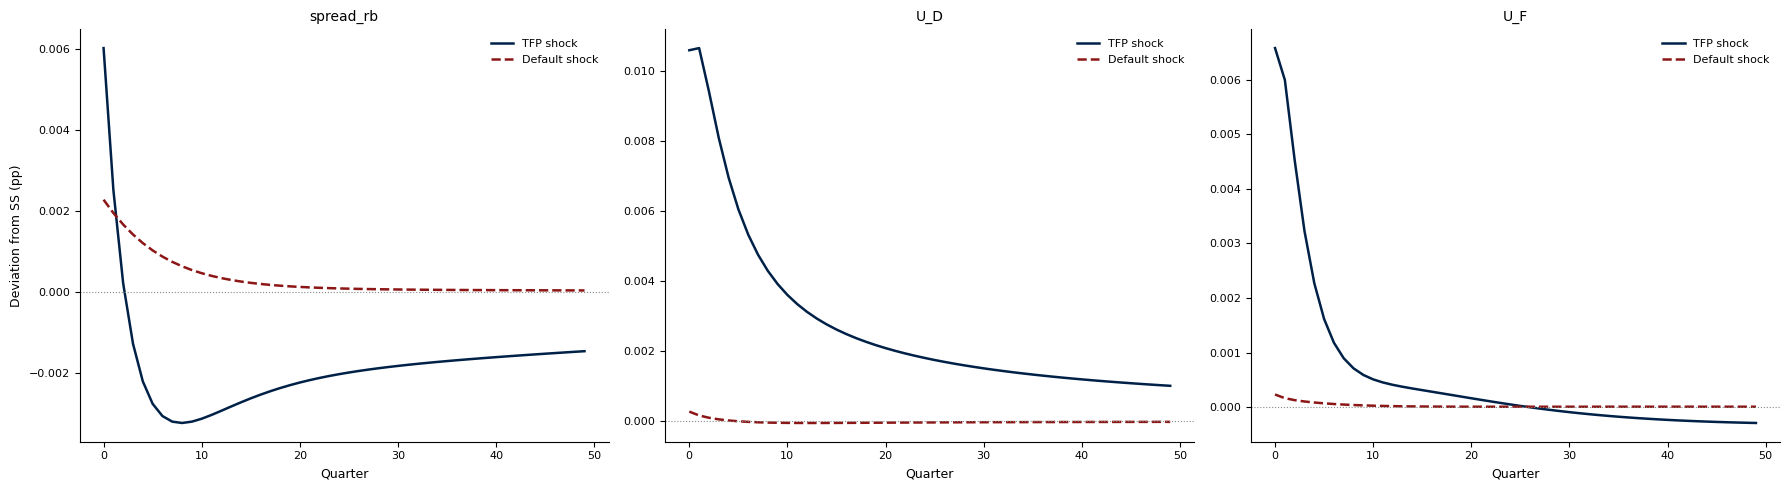

In [ ]:
# Overview: output, consumption, real wage, bank net worth, bond rate
show_irfs([irfs_Z_D, irfs_def_D], ['spread_rb','U_D',"U_F"],['TFP shock', 'Default shock']) 

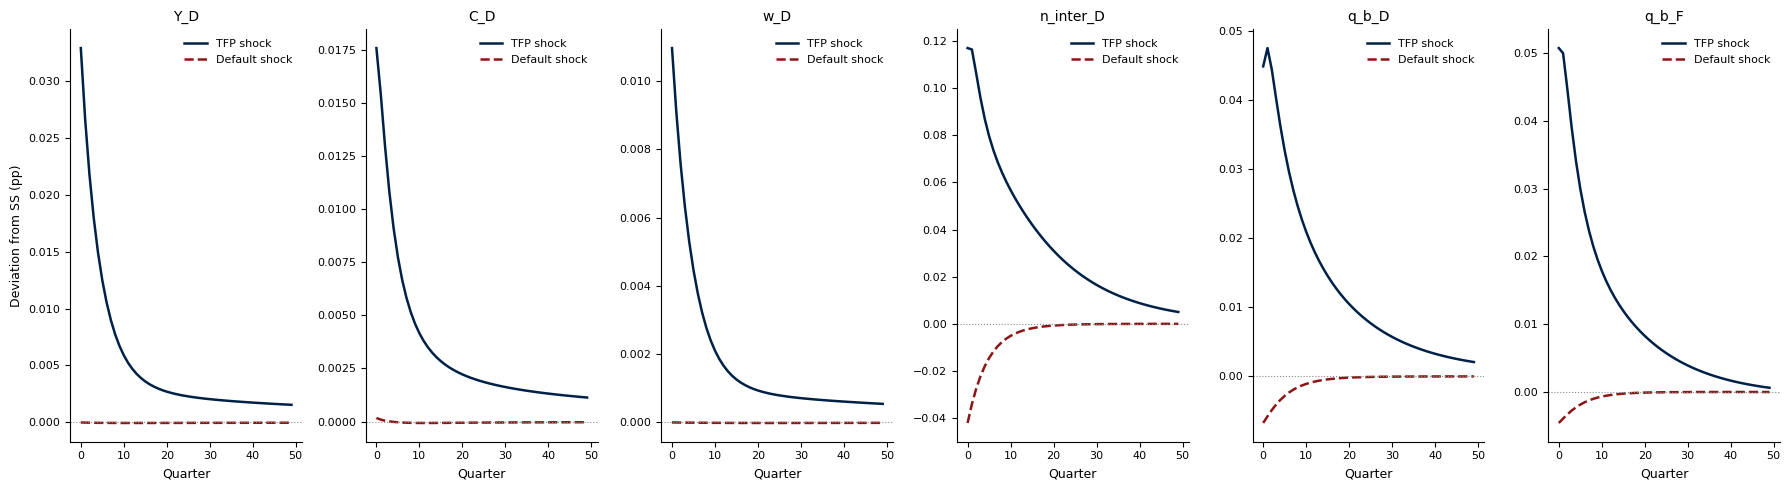

In [ ]:
# Overview: output, consumption, real wage, bank net worth, bond rate
show_irfs([irfs_Z_D, irfs_def_D], 
          ['Y_D', 'C_D', 'w_D', 'n_inter_D', 'q_b_D', 'q_b_F'],
          ['TFP shock', 'Default shock']) 

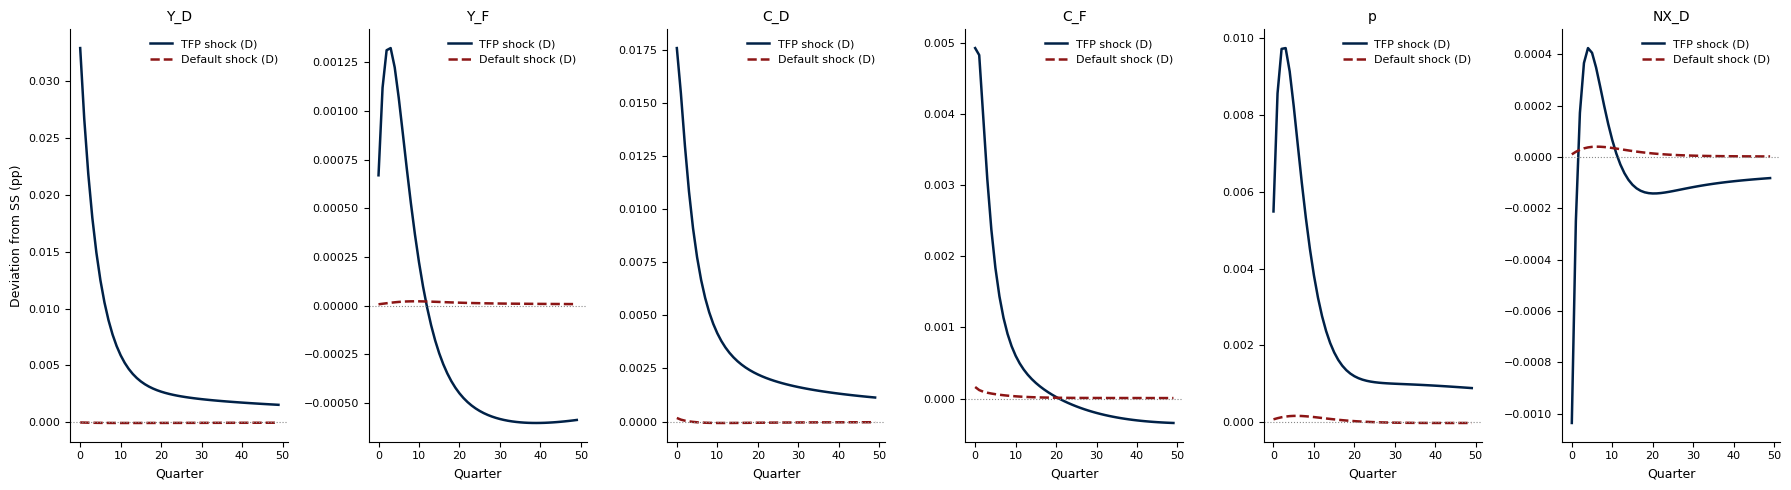

In [ ]:
# ── 1. Output, Consumption & Trade ────────────────────────────────────────
# With flexible prices, inflation is zero; terms of trade p and NX adjust to
# clear goods markets across countries.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['Y_D', 'Y_F', 'C_D', 'C_F', 'p', 'NX_D'])

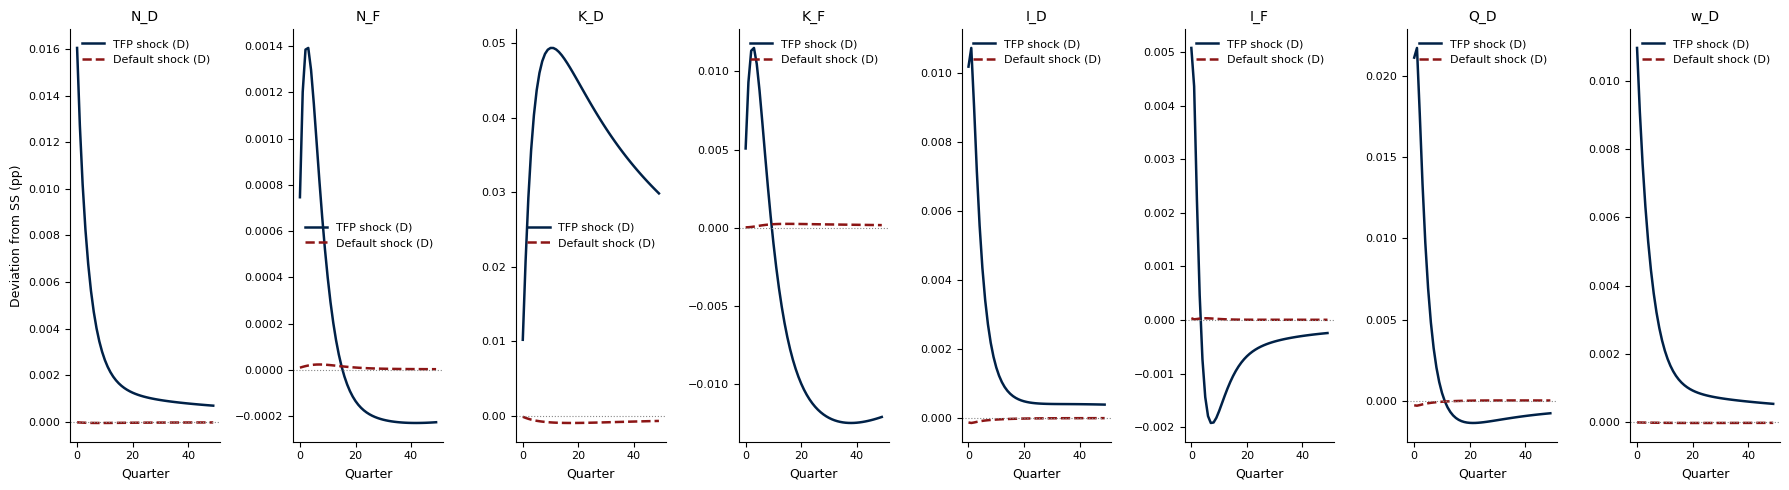

In [ ]:
# ── 2. Labour, Capital & TFP ──────────────────────────────────────────────
# Suggestion: add Q (Tobin's q) and rk — these reveal whether output
# rigidity is coming from the investment or the labour margin.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['N_D', 'N_F', 'K_D', 'K_F', 'I_D', 'I_F', 'Q_D', 'w_D'])


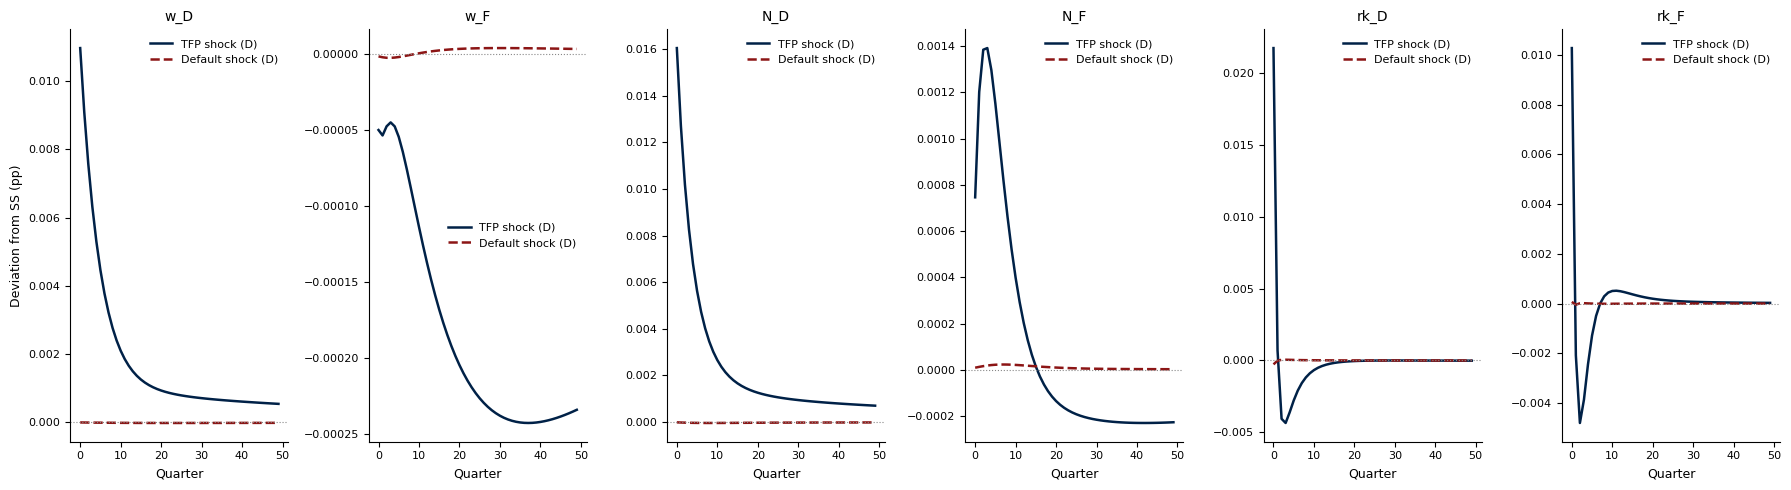

In [ ]:
# ── 3. Factor Prices ──────────────────────────────────────────────────────────
# Under flexible prices mc = 1 always; the interesting margins are factor prices.
# rk = rental rate of capital; w = real wage. Both move with TFP and default shocks.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['w_D', 'w_F', 'N_D', 'N_F', 'rk_D', 'rk_F'])

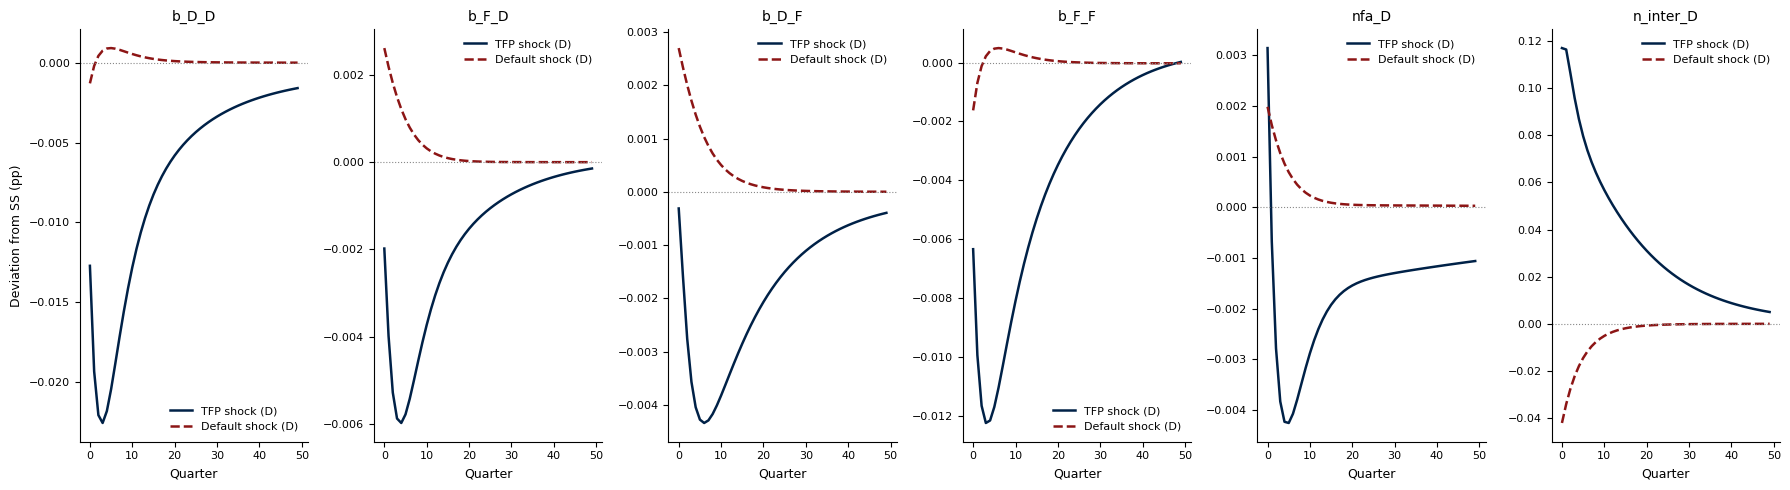

In [ ]:
# ── 4. Bond Holdings & External Position ──────────────────────────────────────
# nfa_D = q_b_F·b_F_D − q_b_D·b_D_F: D's net foreign asset position (in D-goods).
# n_inter_D: D bank net worth — shows financial amplification of sovereign shocks.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_D_D', 'b_F_D', 'b_D_F', 'b_F_F', 'nfa_D', 'n_inter_D'])

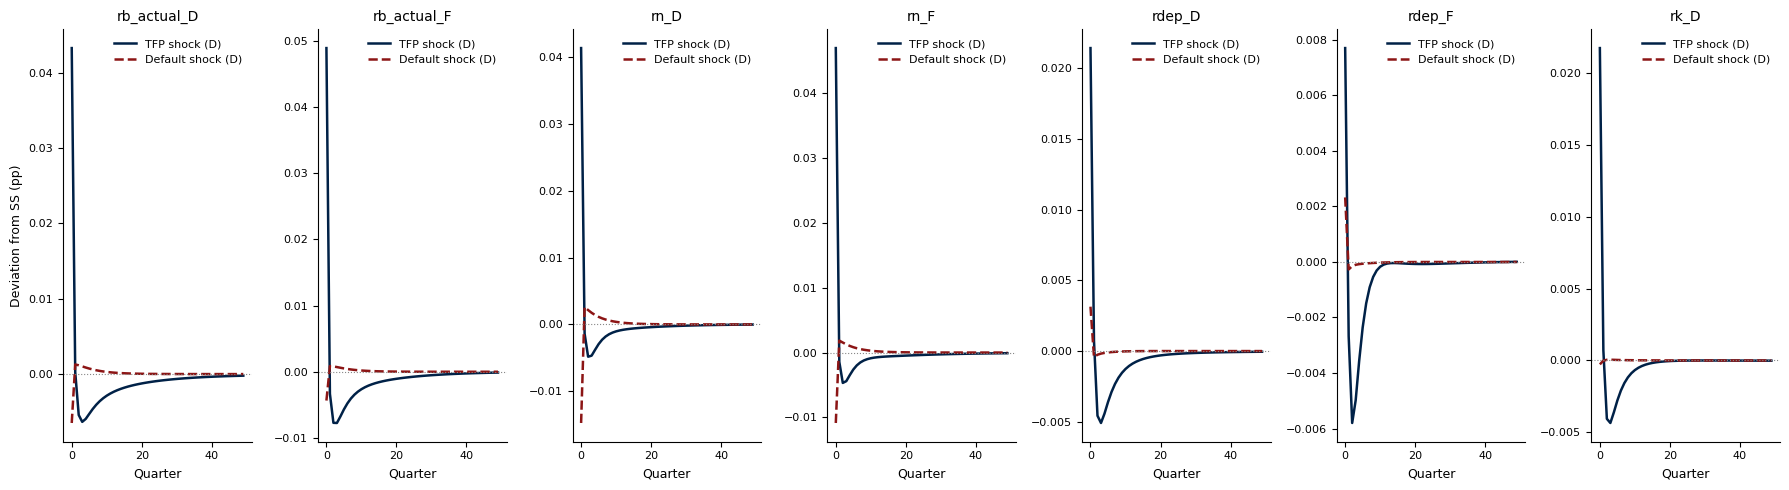

In [ ]:
# ── 5. Rates & Returns ────────────────────────────────────────────────────────
# rdep_D/F are now endogenous (pinned by deposit market clearing in the 23×23 system).
# rk_D: return on physical capital. rn_D: bank portfolio return (mix of rk and rb).
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['rb_actual_D', 'rb_actual_F', 'rn_D', 'rn_F', 'rdep_D', 'rdep_F', 'rk_D'])

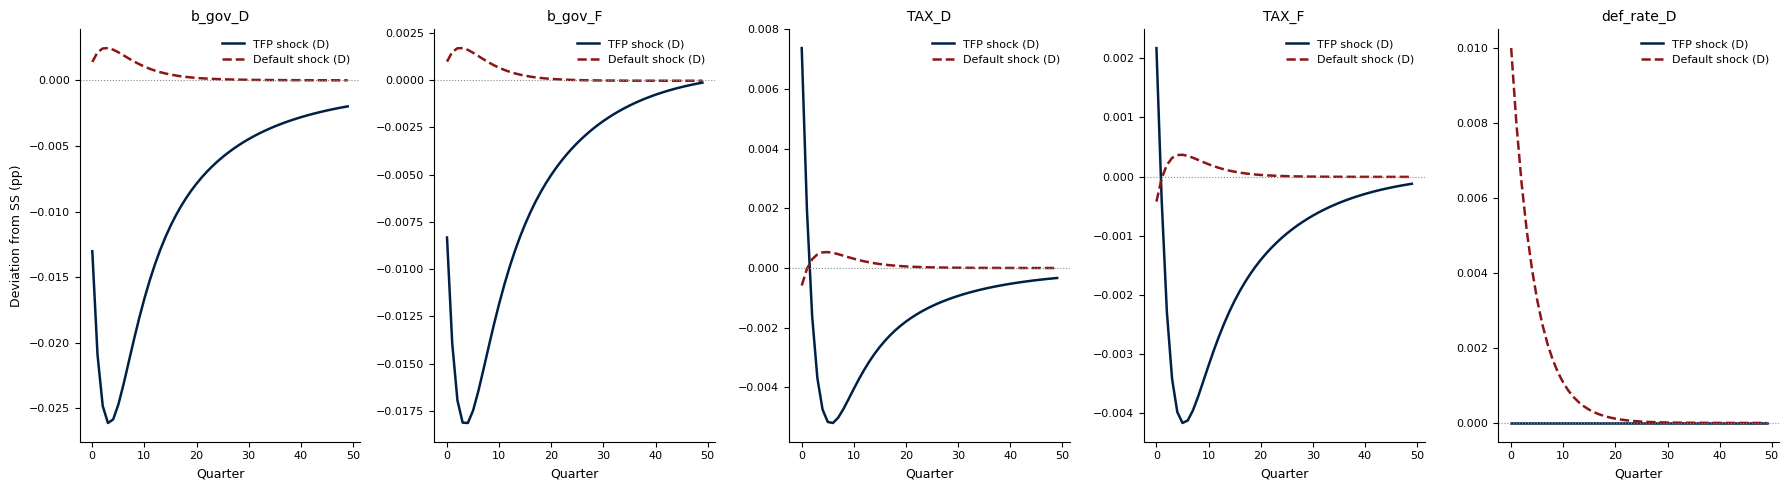

In [ ]:
# ── 6. Fiscal ─────────────────────────────────────────────────────────────
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_gov_D', 'b_gov_F', 'TAX_D', 'TAX_F', 'def_rate_D'])


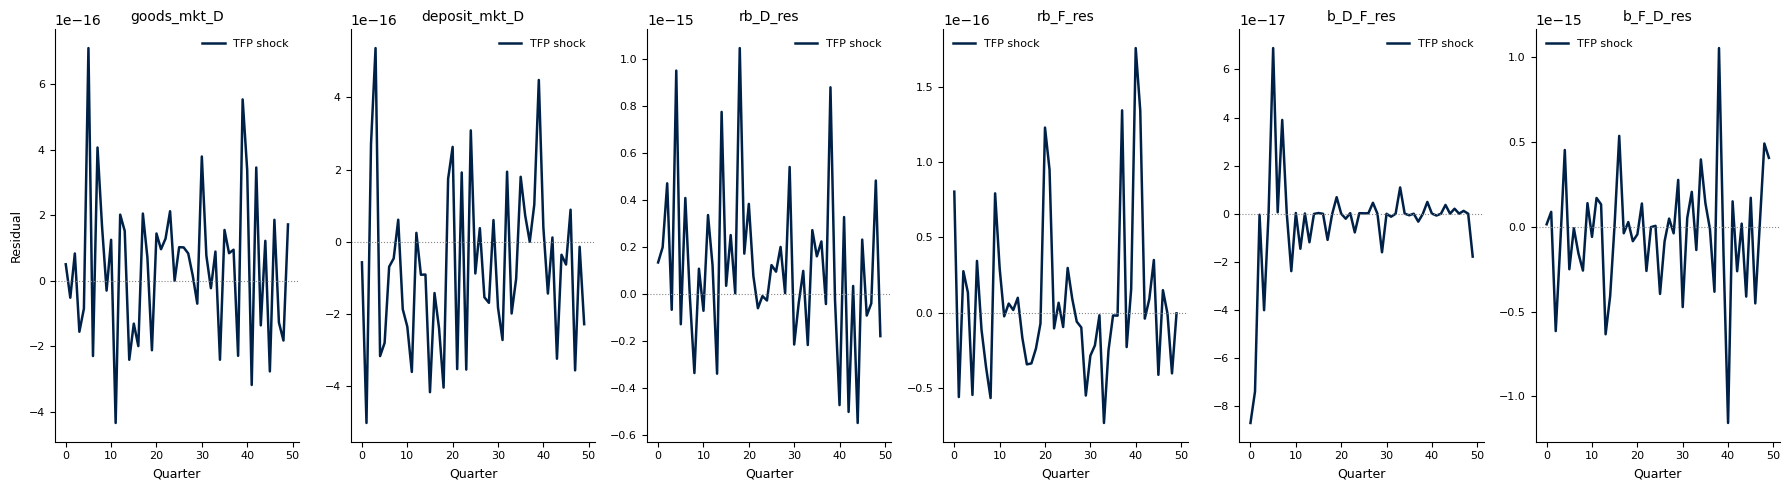

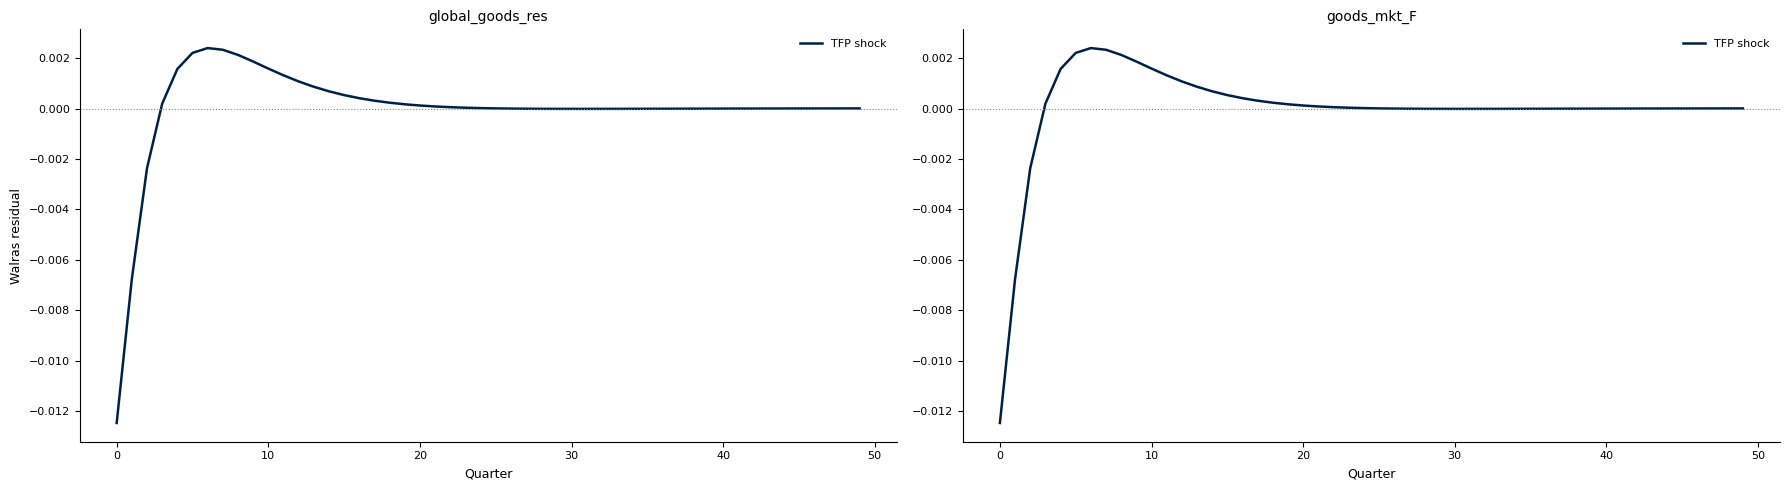

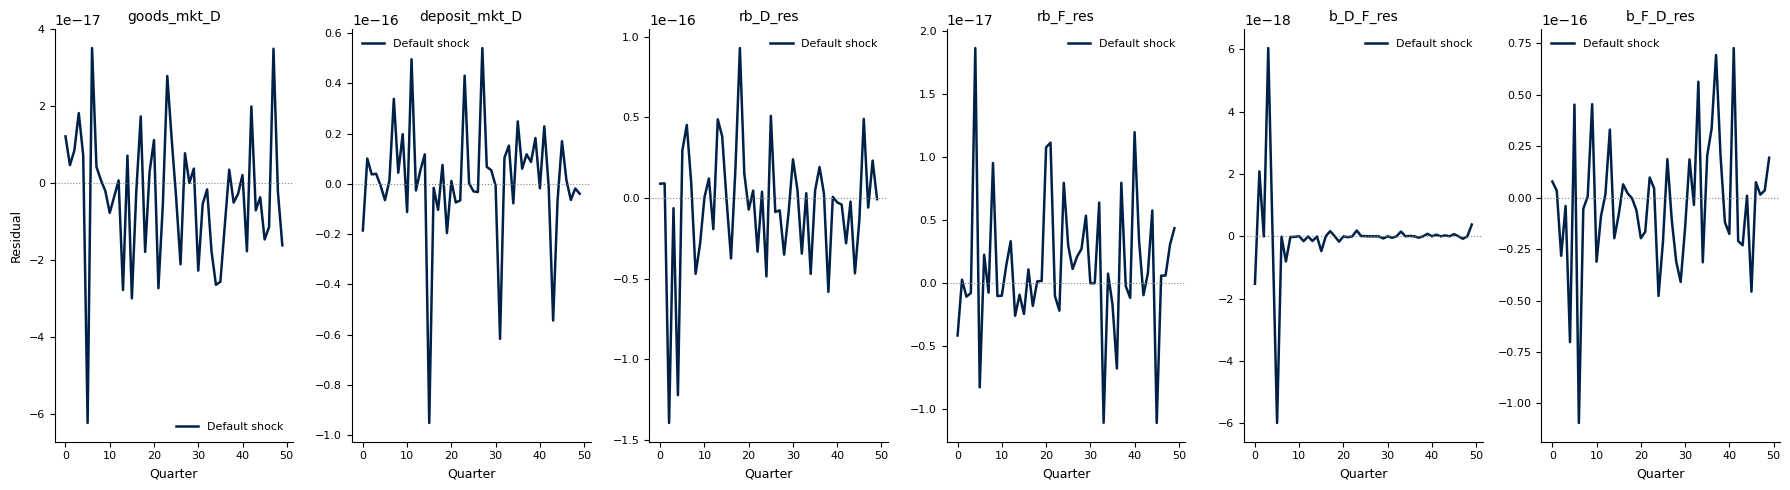

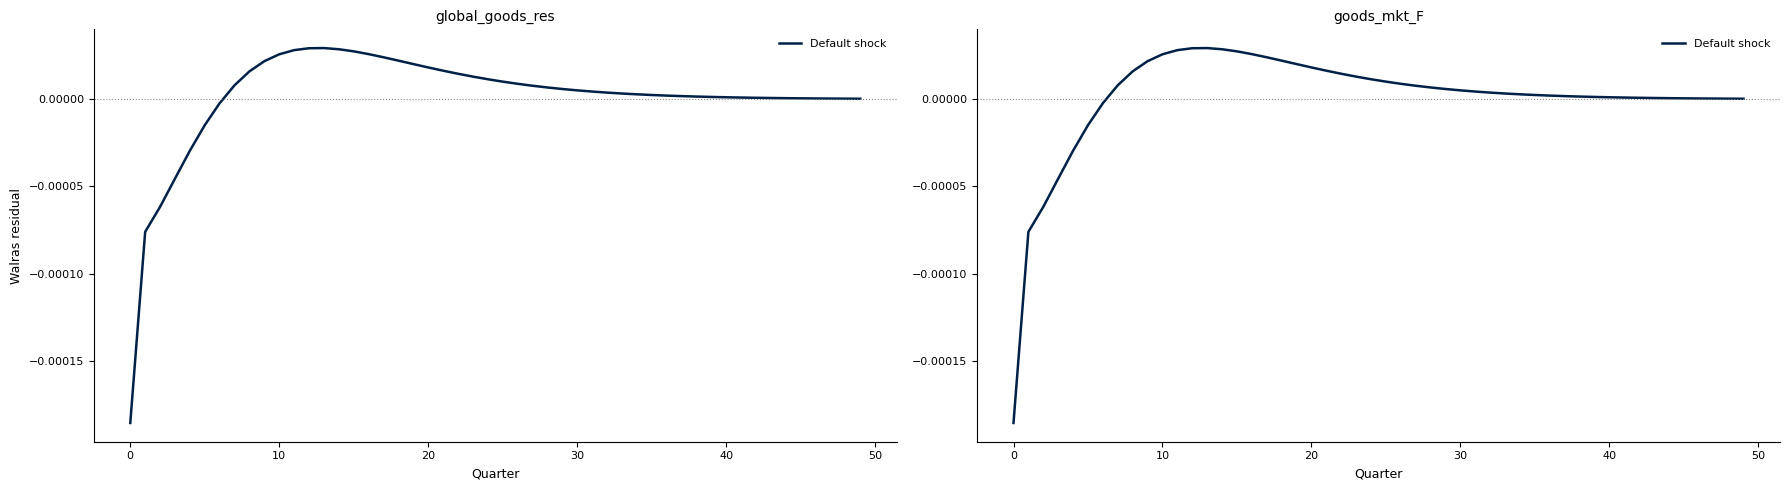

In [ ]:
show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual')  


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONSISTENT n(-1) BALANCE SHEET  +  DELTA CALIBRATION
# ═══════════════════════════════════════════════════════════════════════════════
# equations_D/F.py have been edited so that k_balance_sheet and
# intermediation_P3 both use n_inter(-1) — matching the IC block denominator.
# This cell reloads those modules, rebuilds ha_full, verifies the SS is still
# exact, recomputes the Jacobian, and calibrates Delta to match target
# portfolio share ratios using the analytical IC identity.

import importlib, copy
import equations_D, equations_F
importlib.reload(equations_D)
importlib.reload(equations_F)

from equations_D import (
    capital_adj_D, labor_D,
    labor_market_D, labor_demand_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D,
    cap_adj_cost_inter_D, macro_pru_tax_D,
    intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, government_default_D,
    divert_bond_foc_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D, deposit_return_D,
    bond_return_D, sdf_D, ghh_composite_D,
    welfare_agg_D,
)
from equations_F import (
    capital_adj_F, labor_F,
    labor_market_F, labor_demand_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F,
    cap_adj_cost_inter_F, macro_pru_tax_F,
    intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, government_default_F,
    divert_bond_foc_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F, deposit_return_F,
    bond_return_F, sdf_F, ghh_composite_F,
    welfare_agg_F,
)
from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_level_anchors, divert_portfolio_adj, bond_yield,
    global_goods_mkt, external_account_D,
)

# ── Rebuild inner financial blocks ────────────────────────────────────────────
financial_solved_D2 = sj.combine([
    intermediation_P1_D, intermediation_IC_D,
]).solved(
    unknowns={'nu_K_D':  float(ss_final['nu_K_D']),
              'nu_bD_D': float(ss_final['nu_bD_D']),
              'nu_bF_D': float(ss_final['nu_bF_D']),
              'eta_D':   float(ss_final['eta_D']),
              'theta_D': float(ss_final['theta_D'])},
    targets=['nu_K_res_D', 'nu_bD_res_D', 'nu_bF_res_D', 'eta_res_D', 'ic_res_D'],
    solver='broyden_custom'
)
financial_solved_F2 = sj.combine([
    intermediation_P1_F, intermediation_IC_F,
]).solved(
    unknowns={'nu_K_F':  float(ss_final['nu_K_F']),
              'nu_bF_F': float(ss_final['nu_bF_F']),
              'nu_bD_F': float(ss_final['nu_bD_F']),
              'eta_F':   float(ss_final['eta_F']),
              'theta_F': float(ss_final['theta_F'])},
    targets=['nu_K_res_F', 'nu_bF_res_F', 'nu_bD_res_F', 'eta_res_F', 'ic_res_F'],
    solver='broyden_custom'
)

ha_full2 = sj.create_model([
    deposit_return_D, hh_extended_D, ghh_composite_D, sdf_D,
    government_default_D, financial_solved_D2, bond_return_D, bank_return_D,
    cap_adj_cost_inter_D, macro_pru_tax_D, intermediation_P2_D,
    intermediation_P3_D, k_balance_sheet_D, capital_adj_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    labor_D, labor_market_D, labor_demand_D,
    banker_div_res_D, market_clearing_D, welfare_agg_D,
    deposit_return_F, hh_extended_F, ghh_composite_F, sdf_F,
    government_default_F, financial_solved_F2, bond_return_F, bank_return_F,
    cap_adj_cost_inter_F, macro_pru_tax_F, intermediation_P2_F,
    intermediation_P3_F, k_balance_sheet_F, capital_adj_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    labor_F, labor_market_F, labor_demand_F,
    banker_div_res_F, market_clearing_F, welfare_agg_F,
    ces_price_D, import_demand_D, ces_price_F, import_demand_F,
    trade_balance, external_account_D, domestic_bond_clearing, bond_yield,
    portfolio_level_anchors, divert_portfolio_adj,
    divert_bond_foc_D, divert_bond_foc_F,
    global_goods_mkt,
], name='Full 2-Country — consistent n(-1)') 

# ── Verify SS residuals are still exact after the n(-1) edit ─────────────────
# At SS: n_inter(-1) = n_inter, so k_balance_sheet and intermediation_P3
# evaluate identically to before. All residuals must remain < 1e-8.
residuals_check = ha_full2.residuals(ss_final)
max_res = max(abs(v) for v in residuals_check.values())
print(f'Max SS residual after n(-1) fix: {max_res:.2e}  '
      f'({"PASS" if max_res < 1e-6 else "FAIL"})')

# ── DELTA CALIBRATION ─────────────────────────────────────────────────────────
# Goal: find Delta_bD_D, Delta_bF_D (D-bank) and Delta_bF_F, Delta_bD_F (F-bank)
# such that the IC lambda_gk matches a target AND the divertability RATIO
# Delta_bF / Delta_bD = `delta_ratio` (foreign bonds are less safe than domestic).
#
# From steady_auxilliary:
#   lambda_gk = f / (theta_div * (1/beta/(1+rn) - (1-f)))
# → theta_div_target = f / (lambda_gk_target * (1/beta/(1+rn) - (1-f)))
# → Delta_bD = (theta_div_target - kappa) / (phi_bD + delta_ratio * phi_bF)
# → Delta_bF = delta_ratio * Delta_bD
#
# TARGET PORTFOLIO SHARE RATIOS  (edit to match your data / calibration)
# These are bond holdings as a FRACTION OF BANK NET WORTH.
# The ratio phi_bD / phi_bF pins the domestic/foreign bond composition.
# lambda_gk_target: GK (2011) benchmark ≈ 0.35; smaller = tighter IC.

# ── User-set targets ──────────────────────────────────────────────────────────
phi_bD_D_target   = float(ss_final['q_b_D']) * float(ss_final['b_D_D']) / float(ss_final['n_inter_D'])
phi_bF_D_target   = float(ss_final['q_b_F']) * float(ss_final['b_F_D']) / float(ss_final['n_inter_D'])
phi_bF_F_target   = float(ss_final['q_b_F']) * float(ss_final['b_F_F']) / (float(ss_final['p']) * float(ss_final['n_inter_F']))
phi_bD_F_target   = float(ss_final['q_b_D']) * float(ss_final['b_D_F']) / (float(ss_final['p']) * float(ss_final['n_inter_F']))

lambda_gk_D_target = 0.35   # target GK divertability fraction, D-bank
lambda_gk_F_target = 0.35   # target GK divertability fraction, F-bank
delta_ratio        = 2.0    # Delta_bForeign / Delta_bDomestic (foreign less safe)

print(f'\nSS portfolio shares (as fraction of NW):')
print(f'  D-bank: phi_bD_D = {phi_bD_D_target:.4f},  phi_bF_D = {phi_bF_D_target:.4f}')
print(f'  F-bank: phi_bF_F = {phi_bF_F_target:.4f},  phi_bD_F = {phi_bD_F_target:.4f}')

def calibrate_delta(ss, country, lambda_gk_tgt, ratio):
    """
    Analytically solve for Delta_domestic and Delta_foreign so that:
      (a) IC lambda_gk = lambda_gk_tgt at the solved SS portfolio shares
      (b) Delta_foreign = ratio * Delta_domestic
    Returns (Delta_dom, Delta_for, feasible, diagnostics_dict).
    """
    f    = float(ss[f'f_{country}'])
    beta = float(ss[f'beta_{country}'])
    rn   = float(ss[f'rn_{country}'])
    n    = float(ss[f'n_inter_{country}'])
    Q    = float(ss[f'Q_{country}'])
    K    = float(ss[f'K_{country}'])
    p_d  = float(ss['p']) if country == 'F' else 1.0

    if country == 'D':
        q_dom, b_dom = float(ss['q_b_D']), float(ss['b_D_D'])
        q_for, b_for = float(ss['q_b_F']), float(ss['b_F_D'])
    else:
        q_dom, b_dom = float(ss['q_b_F']), float(ss['b_F_F'])
        q_for, b_for = float(ss['q_b_D']), float(ss['b_D_F'])

    kappa   = Q * K / n
    phi_dom = q_dom * b_dom / (p_d * n)
    phi_for = q_for * b_for / (p_d * n)

    # Required theta_div for target lambda_gk
    denom_ic       = 1.0 / (beta * (1.0 + rn)) - (1.0 - f)
    theta_div_tgt  = f / (lambda_gk_tgt * denom_ic)
    residual       = theta_div_tgt - kappa

    if residual <= 0:
        # kappa alone already exceeds theta_div_target: cannot achieve target lambda_gk
        # with positive Delta. Target lambda_gk is too low — report and return NaN.
        feasible = False
        Delta_dom = Delta_for = float('nan')
    else:
        Delta_dom = residual / (phi_dom + ratio * phi_for)
        Delta_for = ratio * Delta_dom
        feasible  = (0.0 < Delta_dom < 1.0) and (0.0 < Delta_for < 1.0)

    implied_lam = f / (theta_div_tgt * denom_ic) if feasible else float('nan')
    diag = dict(country=country, kappa=kappa, phi_dom=phi_dom, phi_for=phi_for,
                theta_div_tgt=theta_div_tgt, Delta_dom=Delta_dom,
                Delta_for=Delta_for, feasible=feasible, implied_lam=implied_lam)
    return Delta_dom, Delta_for, feasible, diag

dD_bD, dD_bF, ok_D, diag_D = calibrate_delta(ss_final, 'D', lambda_gk_D_target, delta_ratio)
dF_bF, dF_bD, ok_F, diag_F = calibrate_delta(ss_final, 'F', lambda_gk_F_target, delta_ratio)

for d in [diag_D, diag_F]:
    c = d['country']
    print(f'\n── {c}-bank Delta calibration ──────────────────────────────')
    print(f'  kappa_{c}           = {d["kappa"]:.4f}  (capital / NW)')
    print(f'  phi_bdom_{c}        = {d["phi_dom"]:.4f}  (domestic bond / NW)')
    print(f'  phi_bfor_{c}        = {d["phi_for"]:.4f}  (foreign  bond / NW)')
    print(f'  theta_div target    = {d["theta_div_tgt"]:.4f}')
    print(f'  Delta_domestic      = {d["Delta_dom"]:.4f}')
    print(f'  Delta_foreign       = {d["Delta_for"]:.4f}')
    print(f'  implied lambda_gk   = {d["implied_lam"]:.4f}')
    print(f'  feasible (0<Δ<1)    = {d["feasible"]}')

# ── Update calibration dict and rebuild Jacobian with new Deltas ──────────────
cal2 = copy.deepcopy(calibration_start)
if ok_D:
    cal2['Delta_bD_D'] = float(dD_bD)
    cal2['Delta_bF_D'] = float(dD_bF)
    print(f'\nUpdating D-bank: Delta_bD_D={dD_bD:.4f}, Delta_bF_D={dD_bF:.4f}')
else:
    print('\nD-bank target infeasible — keeping original Delta_bD_D, Delta_bF_D.')
    print('  Hint: reduce lambda_gk_D_target or lower b_gov_D to shrink kappa.')

if ok_F:
    cal2['Delta_bF_F'] = float(dF_bF)
    cal2['Delta_bD_F'] = float(dF_bD)
    print(f'Updating F-bank: Delta_bF_F={dF_bF:.4f}, Delta_bD_F={dF_bD:.4f}')
else:
    print('F-bank target infeasible — keeping original Delta_bF_F, Delta_bD_F.')

# Recompute Jacobian using ha_full2 (n(-1)-consistent) at ss_final
print('\nRecomputing Jacobian G2 with n(-1)-consistent balance sheet ...')
G2 = ha_full2.solve_jacobian(
    ss_final, unknowns=unknowns_tp, targets=targets_tp,
    inputs=exogenous, T=T
)
print('G2 computed.')

# Linear IRFs from corrected model
irfs_Z_D2    = G2 @ shock_Z_D
irfs_def_D2  = G2 @ shock_def_D

# Quick perverse-IC check with corrected model
print('\n=== n(-1)-consistent model: default shock diagnostics ===')
print(f'theta_D[0]: {irfs_def_D2["theta_D"][0]*100:+.4f}%  '
      f'(was {irfs_def_D["theta_D"][0]*100:+.4f}%  in original)')
print(f'n_inter_D[0]: {irfs_def_D2["n_inter_D"][0]*100:+.4f}%  '
      f'(was {irfs_def_D["n_inter_D"][0]*100:+.4f}%)')


AttributeError: 'CombinedBlock' object has no attribute 'residuals'

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# NONLINEAR IMPULSE RESPONSES  (vs linear)
# ═══════════════════════════════════════════════════════════════════════════════
# SSJ's solve_impulse_nonlinear iterates the full nonlinear path using
# Newton steps preconditioned by the precomputed Jacobian G2.
# For a 1% shock the linear and nonlinear responses should be very close.
# The nonlinear solve is meaningful for large shocks (>=5%) where the IC
# constraint, the net worth accumulation, and bond price dynamics become
# noticeably nonlinear.

# ── Small shock (1%) — linear vs nonlinear difference should be tiny ──────────
print('Running nonlinear solve (1% shocks)...')
try:
    irfs_Z_D_nl   = ha_full2.solve_impulse_nonlinear(
        ss_final, unknowns=unknowns_tp, targets=targets_tp,
        inputs=shock_Z_D,   T=T, tol=1e-9, verbose=False)
    irfs_def_D_nl = ha_full2.solve_impulse_nonlinear(
        ss_final, unknowns=unknowns_tp, targets=targets_tp,
        inputs=shock_def_D, T=T, tol=1e-9, verbose=False)
    print('Nonlinear solve (1%) complete.')
    nl_ok = True
except Exception as e:
    print(f'solve_impulse_nonlinear not available or failed: {e}')
    print('Falling back to linear IRFs for comparison.')
    irfs_Z_D_nl   = irfs_Z_D2
    irfs_def_D_nl = irfs_def_D2
    nl_ok = False

# ── Large shock (5%) — nonlinear effects become visible ──────────────────────
if nl_ok:
    rho_Z_D_large        = 0.8
    rho_def_D_large      = 0.8
    dZ_D_large           = 0.05 * rho_Z_D_large    ** np.arange(T)
    dShock_def_D_large   = 0.05 * rho_def_D_large  ** np.arange(T)

    shock_Z_D_large   = {'Z_D': dZ_D_large,   'Z_F': np.zeros(T),
                         'shock_def_D': np.zeros(T), 'shock_def_F': np.zeros(T)}
    shock_def_D_large = {'Z_D': np.zeros(T),  'Z_F': np.zeros(T),
                         'shock_def_D': dShock_def_D_large, 'shock_def_F': np.zeros(T)}

    irfs_Z_D_large_lin   = G2 @ shock_Z_D_large
    irfs_def_D_large_lin = G2 @ shock_def_D_large

    print('Running nonlinear solve (5% shocks)...')
    try:
        irfs_Z_D_large_nl   = ha_full2.solve_impulse_nonlinear(
            ss_final, unknowns=unknowns_tp, targets=targets_tp,
            inputs=shock_Z_D_large,   T=T, tol=1e-9, verbose=False)
        irfs_def_D_large_nl = ha_full2.solve_impulse_nonlinear(
            ss_final, unknowns=unknowns_tp, targets=targets_tp,
            inputs=shock_def_D_large, T=T, tol=1e-9, verbose=False)
        print('Nonlinear solve (5%) complete.')
    except Exception as e:
        print(f'Large-shock nonlinear solve failed: {e}')
        irfs_Z_D_large_nl   = irfs_Z_D_large_lin
        irfs_def_D_large_nl = irfs_def_D_large_lin


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPARISON PLOTS: original linear vs n(-1)-consistent linear vs nonlinear
# ═══════════════════════════════════════════════════════════════════════════════

T_plot = 40

# ── Panel 1: effect of n(-1) balance-sheet fix on default shock IRFs ─────────
print('── Default shock: original vs n(-1)-consistent (linear) ──')
show_irfs(
    [irfs_def_D, irfs_def_D2],
    variables=['theta_D', 'n_inter_D', 'K_D', 'q_b_D', 'rn_D', 'Y_D'],
    labels=['Original (inconsistent n)', 'n(-1)-consistent'],
    ylabel='Deviation from SS (pp)', T_plot=T_plot,
)

# ── Panel 2: effect of n(-1) fix on TFP shock IRFs ───────────────────────────
print('── TFP shock: original vs n(-1)-consistent (linear) ──')
show_irfs(
    [irfs_Z_D, irfs_Z_D2],
    variables=['theta_D', 'n_inter_D', 'K_D', 'I_D', 'Y_D', 'C_D'],
    labels=['Original (inconsistent n)', 'n(-1)-consistent'],
    ylabel='Deviation from SS (pp)', T_plot=T_plot,
)

# ── Panel 3: linear vs nonlinear, 1% shocks ───────────────────────────────────
if nl_ok:
    print('── TFP shock 1%: linear vs nonlinear ──')
    show_irfs(
        [irfs_Z_D2, irfs_Z_D_nl],
        variables=['Y_D', 'C_D', 'K_D', 'theta_D', 'n_inter_D', 'q_b_D'],
        labels=['Linear (1%)', 'Nonlinear (1%)'],
        ylabel='Deviation from SS (pp)', T_plot=T_plot,
    )
    print('── Default shock 1%: linear vs nonlinear ──')
    show_irfs(
        [irfs_def_D2, irfs_def_D_nl],
        variables=['theta_D', 'n_inter_D', 'q_b_D', 'rb_actual_D', 'rn_D', 'Y_D'],
        labels=['Linear (1%)', 'Nonlinear (1%)'],
        ylabel='Deviation from SS (pp)', T_plot=T_plot,
    )

# ── Panel 4: linear vs nonlinear, 5% shock — where nonlinearity matters ──────
if nl_ok:
    print('── TFP shock 5%: linear vs nonlinear (rescaled to 1% for comparability) ──')
    scale = 0.01 / 0.05   # rescale 5% → 1% for visual comparability
    irfs_Z_D_large_lin_sc   = {k: v * scale for k, v in irfs_Z_D_large_lin.items()}
    irfs_Z_D_large_nl_sc    = {k: v * scale for k, v in irfs_Z_D_large_nl.items()}
    show_irfs(
        [irfs_Z_D2, irfs_Z_D_large_lin_sc, irfs_Z_D_large_nl_sc],
        variables=['Y_D', 'C_D', 'K_D', 'theta_D', 'n_inter_D', 'I_D'],
        labels=['Linear 1%', 'Linear 5% (rescaled)', 'Nonlinear 5% (rescaled)'],
        ylabel='Deviation from SS (pp, rescaled to 1%)', T_plot=T_plot,
    )
    print('── Default shock 5%: linear vs nonlinear (rescaled to 1%) ──')
    irfs_def_D_large_lin_sc = {k: v * scale for k, v in irfs_def_D_large_lin.items()}
    irfs_def_D_large_nl_sc  = {k: v * scale for k, v in irfs_def_D_large_nl.items()}
    show_irfs(
        [irfs_def_D2, irfs_def_D_large_lin_sc, irfs_def_D_large_nl_sc],
        variables=['theta_D', 'n_inter_D', 'q_b_D', 'rb_actual_D', 'Y_D', 'C_D'],
        labels=['Linear 1%', 'Linear 5% (rescaled)', 'Nonlinear 5% (rescaled)'],
        ylabel='Deviation from SS (pp, rescaled to 1%)', T_plot=T_plot,
    )


## Section 3.1–3.2 — Verification: λ_gk Range & Market Clearing

In [ ]:
# ── 3.1: lambda_gk acceptance range ───────────────────────────────────────────
lam_D = float(ss_final['lambda_gk_D'])
lam_F = float(ss_final['lambda_gk_F'])
print(f"lambda_gk_D = {lam_D:.4f}  (acceptable: 0.10–0.45)")
print(f"lambda_gk_F = {lam_F:.4f}  (acceptable: 0.10–0.45)")
assert 0.10 <= lam_D <= 0.45, f"lambda_gk_D = {lam_D:.4f} out of [0.10, 0.45]"
assert 0.10 <= lam_F <= 0.45, f"lambda_gk_F = {lam_F:.4f} out of [0.10, 0.45]"
print("lambda_gk check PASSED.")

# ── 3.2: Market-clearing assertions ───────────────────────────────────────────
markets = [
    'goods_mkt_D', 'goods_mkt_F',
    'deposit_mkt_D', 'deposit_mkt_F',
    'global_goods_res',
    'K_res_D', 'K_res_F',
    'ic_res_D', 'ic_res_F',
    'ca_res_D', 'div_res_D', 'div_res_F',
]
tol = 1e-6
all_clear = True
for m in markets:
    try:
        val = float(ss_final[m])
        ok  = abs(val) < tol
        if not ok: all_clear = False
        print(f"  {m:<28s} = {val:+.2e}  [{'OK' if ok else 'FAIL'}]")
    except KeyError:
        print(f"  {m:<28s} = [not in SS dict — check model]")
print("\nAll markets clear to tolerance." if all_clear
      else "\nWARNING: One or more markets failed — check calibration.")


## Section 3.3 — Pure Default-Risk Shock (`writeoff_enabled = 0`)

Isolates the bank IC/collateral channel. With `writeoff_enabled_D = 0`, `def_rate_D` enters **only** through the divertability penalty `psi_lambda_B_D·def_rate_D(+1)` in `intermediation_IC_D` and `divert_bond_foc_D`. No direct write-off appears in the government budget or bond returns.

Robustness check: re-run with `psi_lambda_B_D = 0` (IC channel off). The Jacobian changes but the SS is identical (since `def_rate=0` at SS). A smaller trough confirms amplification runs through the bank IC channel.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3.3 — Pure Default-Risk Shock
# ═══════════════════════════════════════════════════════════════════════════════
assert calibration_start['writeoff_enabled_D'] == 0.0, "Set writeoff_enabled_D=0 for pure risk shock"
assert calibration_start['writeoff_enabled_F'] == 0.0, "Set writeoff_enabled_F=0 for pure risk shock"

rho_def   = 0.8
dImpact   = 0.01   # 1 pp on impact
T_irf     = T
shock_path = dImpact * rho_def ** np.arange(T_irf)

irfs_def_D_pure = G.apply({'shock_def_D': shock_path})

print("=== Pure default-risk shock (writeoff_enabled_D = 0) ===")
print(f"  Impact theta_D:       {irfs_def_D_pure['theta_D'][0]*100:+.3f} pp")
print(f"  Impact n_inter_D:     {irfs_def_D_pure['n_inter_D'][0]*100:+.3f} %")
print(f"  Impact q_b_D:         {irfs_def_D_pure['q_b_D'][0]*100:+.3f} %")
print(f"  Impact rb_actual_D:   {irfs_def_D_pure['rb_actual_D'][0]*100:+.3f} pp")
print(f"  Trough Y_D:           {irfs_def_D_pure['Y_D'].min()*100:+.3f} %")

# ── Robustness: psi_lambda_B_D = 0 (no state-dependent collateral effect) ─────
# SS is identical to ss_final (def_rate=0 in SS, so psi_lambda_B has no SS effect).
# Only the Jacobian differs.
ss_no_ic = copy.deepcopy(ss_final)
ss_no_ic.toplevel['psi_lambda_B_D'] = 0.0

G_no_ic = ha_full.solve_jacobian(
    ss_no_ic, unknowns=unknowns_tp, targets=targets_tp, inputs=exogenous, T=T
)
irfs_def_D_noIC = G_no_ic.apply({'shock_def_D': shock_path})

print(f"\n[Robustness: psi_lambda_B_D=0]  Trough Y_D = {irfs_def_D_noIC['Y_D'].min()*100:+.3f} %")
print("If |trough| is smaller, amplification confirmed via bank IC channel.")

show_irfs(
    [irfs_def_D_pure, irfs_def_D_noIC],
    labels=['Pure risk shock (IC on)', 'Pure risk shock (IC off)'],
    variables=['Y_D', 'n_inter_D', 'theta_D', 'q_b_D', 'rb_actual_D', 'I_D'],
)
